`label_ids_to_fuse` unset. No instance will be fused.


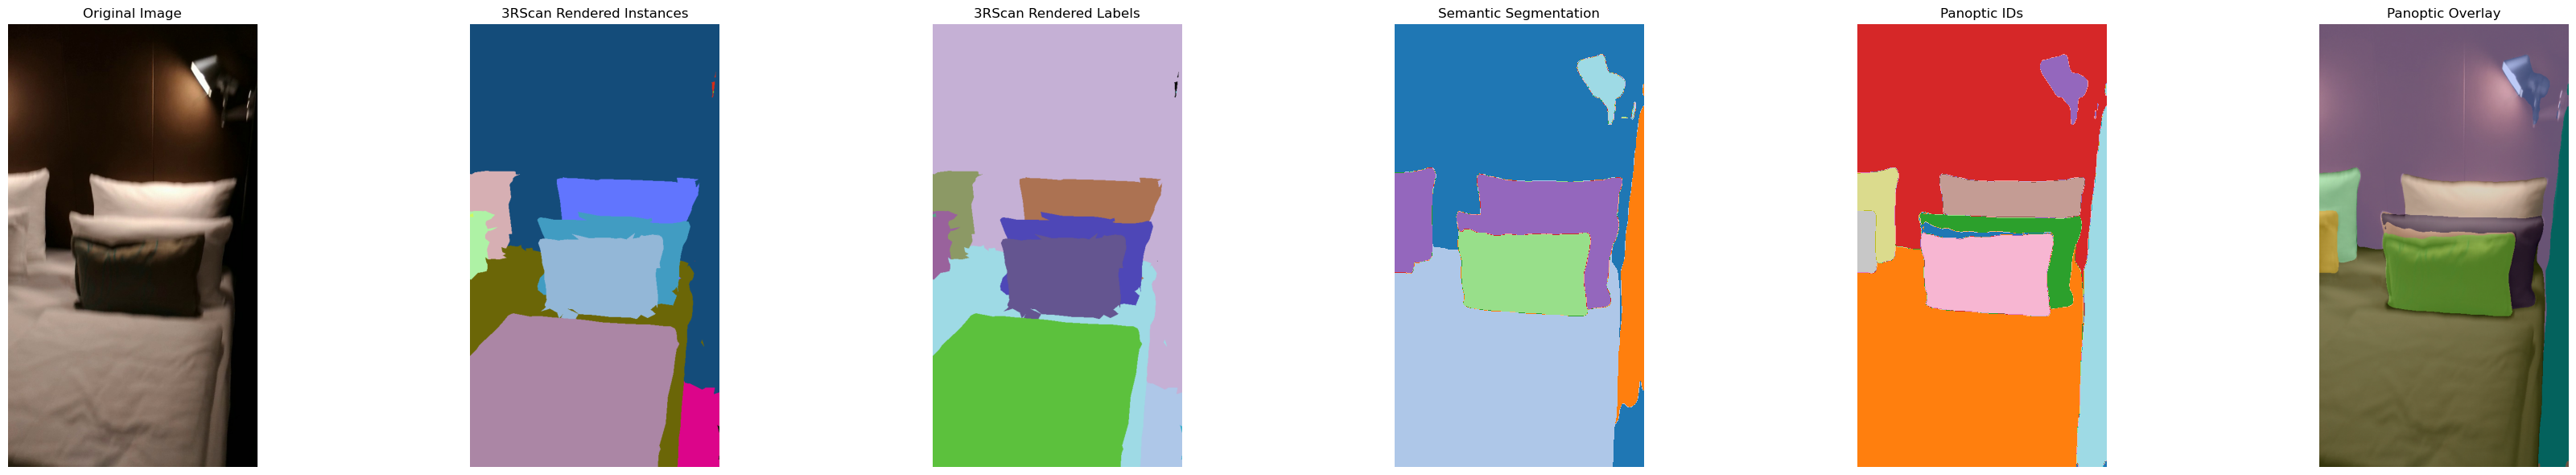

Panoptic segments detected: 9
{'id': 1, 'label_id': 7, 'was_fused': False, 'score': 0.987269, 'label_name': 'bed '}
{'id': 2, 'label_id': 57, 'was_fused': False, 'score': 0.99809, 'label_name': 'pillow'}
{'id': 3, 'label_id': 0, 'was_fused': False, 'score': 0.999293, 'label_name': 'wall'}
{'id': 4, 'label_id': 134, 'was_fused': False, 'score': 0.981049, 'label_name': 'sconce'}
{'id': 5, 'label_id': 57, 'was_fused': False, 'score': 0.992139, 'label_name': 'pillow'}
{'id': 6, 'label_id': 39, 'was_fused': False, 'score': 0.988688, 'label_name': 'cushion'}
{'id': 7, 'label_id': 57, 'was_fused': False, 'score': 0.987867, 'label_name': 'pillow'}
{'id': 8, 'label_id': 57, 'was_fused': False, 'score': 0.995894, 'label_name': 'pillow'}
{'id': 9, 'label_id': 18, 'was_fused': False, 'score': 0.930122, 'label_name': 'curtain'}


In [10]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# Use a COCO-panoptic checkpoint to match the COCO sample image.
checkpoint = "facebook/mask2former-swin-large-ade-panoptic"
processor = AutoImageProcessor.from_pretrained(checkpoint)
model = Mask2FormerForUniversalSegmentation.from_pretrained(checkpoint)

image_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000000.color.jpg"
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Local image not found: {image_path}")

instances_path = image_path.replace(".color.jpg", ".rendered.instances.png")
labels_path = image_path.replace(".color.jpg", ".rendered.labels.png")

if not os.path.exists(instances_path):
    raise FileNotFoundError(f"Rendered instances image not found: {instances_path}")
if not os.path.exists(labels_path):
    raise FileNotFoundError(f"Rendered labels image not found: {labels_path}")

image = Image.open(image_path).convert("RGB")
image = image.rotate(-90, expand=True)

def align_to_reference_orientation(img, reference_size):
    if img.size == reference_size:
        return img
    candidates = [
        img.rotate(-90, expand=True),
        img.rotate(90, expand=True),
        img.rotate(180, expand=True),
    ]
    for candidate in candidates:
        if candidate.size == reference_size:
            return candidate
    return img

rendered_instances = Image.open(instances_path).convert("RGB")
rendered_instances = align_to_reference_orientation(rendered_instances, image.size)

rendered_labels = Image.open(labels_path)
rendered_labels = align_to_reference_orientation(rendered_labels, image.size)

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

# Panoptic output.
panoptic = processor.post_process_panoptic_segmentation(
    outputs,
    target_sizes=[image.size[::-1]],
    threshold=0.3,
    mask_threshold=0.3,
    overlap_mask_area_threshold=0.7,
)[0]

predicted_panoptic_map = panoptic["segmentation"].cpu().numpy()
segments_info = panoptic["segments_info"]

# Semantic output for comparison.
semantic = processor.post_process_semantic_segmentation(
    outputs, target_sizes=[image.size[::-1]]
)[0].cpu().numpy()

# Colorize panoptic ids.
unique_ids = np.unique(predicted_panoptic_map)
rng = np.random.default_rng(0)
colors = rng.random((len(unique_ids), 3), dtype=np.float32)
color_map = {int(seg_id): colors[i] for i, seg_id in enumerate(unique_ids)}

panoptic_color = np.zeros((*predicted_panoptic_map.shape, 3), dtype=np.float32)
for seg_id in unique_ids:
    panoptic_color[predicted_panoptic_map == seg_id] = color_map[int(seg_id)]

# Blend panoptic colors over the original image.
image_np = np.array(image).astype(np.float32) / 255.0
alpha = 0.5
overlay = (1 - alpha) * image_np + alpha * panoptic_color

# Decode 3RScan rendered instance encoding to readable colors.
rendered_instances_np = np.array(rendered_instances, dtype=np.uint8)
if rendered_instances_np.ndim == 3:
    if np.array_equal(rendered_instances_np[..., 0], rendered_instances_np[..., 1]) and np.array_equal(rendered_instances_np[..., 1], rendered_instances_np[..., 2]):
        rendered_instance_ids = rendered_instances_np[..., 0].astype(np.int32)
    else:
        rendered_instance_ids = (
            rendered_instances_np[..., 0].astype(np.int32)
            + (rendered_instances_np[..., 1].astype(np.int32) << 8)
            + (rendered_instances_np[..., 2].astype(np.int32) << 16)
        )
else:
    rendered_instance_ids = rendered_instances_np.astype(np.int32)

instance_unique_ids = np.unique(rendered_instance_ids)
instance_colors = rng.random((len(instance_unique_ids), 3), dtype=np.float32)
instance_color_map = {int(seg_id): instance_colors[i] for i, seg_id in enumerate(instance_unique_ids)}

rendered_instances_vis = np.zeros((*rendered_instance_ids.shape, 3), dtype=np.float32)
for seg_id in instance_unique_ids:
    rendered_instances_vis[rendered_instance_ids == seg_id] = instance_color_map[int(seg_id)]

rendered_labels_np = np.array(rendered_labels)

fig, axes = plt.subplots(1, 6, figsize=(36, 6))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(rendered_instances_vis)
axes[1].set_title("3RScan Rendered Instances")
axes[1].axis("off")

if rendered_labels_np.ndim == 2:
    axes[2].imshow(rendered_labels_np, cmap="tab20")
else:
    axes[2].imshow(rendered_labels_np)
axes[2].set_title("3RScan Rendered Labels")
axes[2].axis("off")

axes[3].imshow(semantic, cmap="tab20")
axes[3].set_title("Semantic Segmentation")
axes[3].axis("off")

axes[4].imshow(predicted_panoptic_map, cmap="tab20")
axes[4].set_title("Panoptic IDs")
axes[4].axis("off")

axes[5].imshow(overlay)
axes[5].set_title("Panoptic Overlay")
axes[5].axis("off")

plt.tight_layout()
plt.show()

print(f"Panoptic segments detected: {len(segments_info)}")
for s in segments_info[:10]:
    label = model.config.id2label.get(s.get("label_id", -1), "unknown")
    print({**s, "label_name": label})

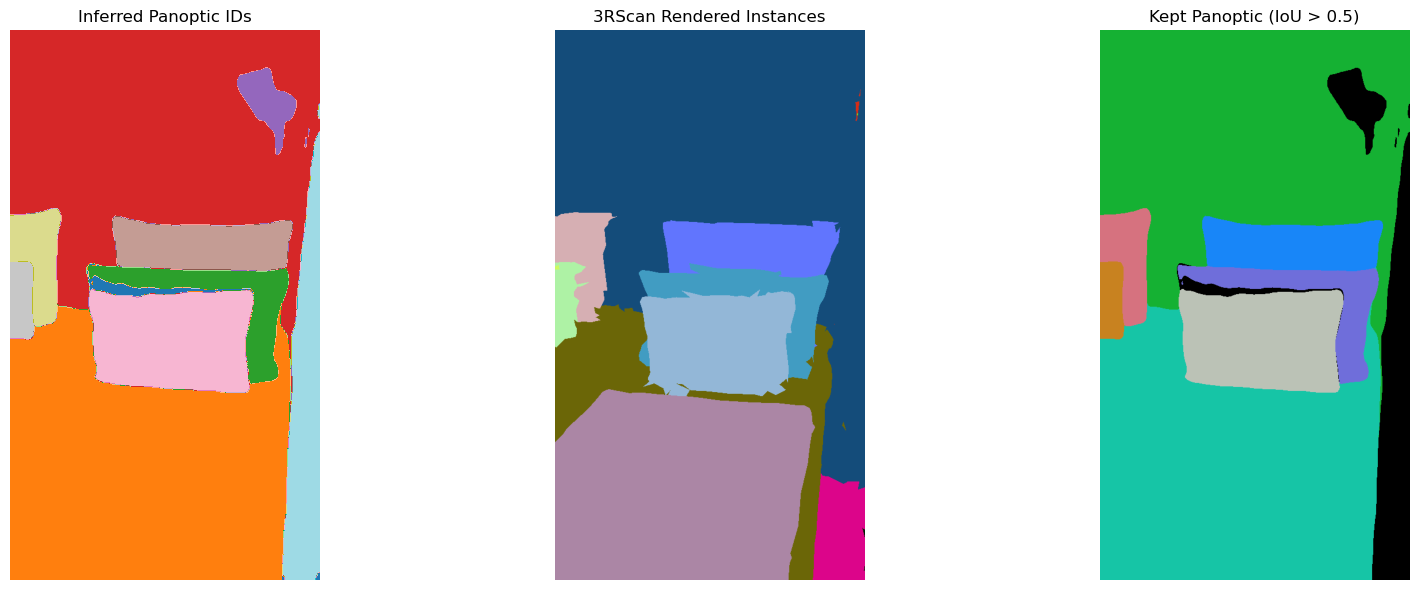

Total inferred panoptic instances (excluding 0): 9
Matched and kept instances (IoU > 0.3): 7
panoptic_id=1 -> rendered_id=25 | IoU=0.738
panoptic_id=2 -> rendered_id=26 | IoU=0.587
panoptic_id=3 -> rendered_id=9 | IoU=0.822
panoptic_id=5 -> rendered_id=27 | IoU=0.856
panoptic_id=6 -> rendered_id=47 | IoU=0.860
panoptic_id=7 -> rendered_id=29 | IoU=0.853
panoptic_id=8 -> rendered_id=30 | IoU=0.848


In [2]:
# Match inferred panoptic instances to 3RScan rendered instances using IoU.
iou_threshold = 0.3

if predicted_panoptic_map.shape != rendered_instance_ids.shape:
    raise ValueError(
        f"Shape mismatch: panoptic={predicted_panoptic_map.shape}, rendered={rendered_instance_ids.shape}"
    )

panoptic_ids = [int(x) for x in np.unique(predicted_panoptic_map) if int(x) != 0]
rendered_ids = [int(x) for x in np.unique(rendered_instance_ids) if int(x) != 0]

best_match_for_panoptic = {}
kept_panoptic_ids = set()

for pan_id in panoptic_ids:
    pan_mask = predicted_panoptic_map == pan_id
    pan_area = int(pan_mask.sum())
    if pan_area == 0:
        continue

    best_rendered_id = None
    best_iou = 0.0

    for rend_id in rendered_ids:
        rend_mask = rendered_instance_ids == rend_id
        inter = int(np.logical_and(pan_mask, rend_mask).sum())
        if inter == 0:
            continue
        union = pan_area + int(rend_mask.sum()) - inter
        iou = inter / union if union > 0 else 0.0

        if iou > best_iou:
            best_iou = iou
            best_rendered_id = rend_id

    if best_rendered_id is not None and best_iou > iou_threshold:
        best_match_for_panoptic[pan_id] = {
            "rendered_instance_id": best_rendered_id,
            "iou": best_iou,
        }
        kept_panoptic_ids.add(pan_id)

filtered_panoptic_map = np.zeros_like(predicted_panoptic_map)
for pan_id in kept_panoptic_ids:
    filtered_panoptic_map[predicted_panoptic_map == pan_id] = pan_id

# Create a color visualization for kept instances.
kept_ids = np.unique(filtered_panoptic_map)
kept_ids = kept_ids[kept_ids != 0]
filtered_color = np.zeros((*filtered_panoptic_map.shape, 3), dtype=np.float32)

local_rng = np.random.default_rng(42)
if len(kept_ids) > 0:
    kept_colors = local_rng.random((len(kept_ids), 3), dtype=np.float32)
    for i, pan_id in enumerate(kept_ids):
        filtered_color[filtered_panoptic_map == int(pan_id)] = kept_colors[i]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(predicted_panoptic_map, cmap="tab20")
axes[0].set_title("Inferred Panoptic IDs")
axes[0].axis("off")

axes[1].imshow(rendered_instances_vis)
axes[1].set_title("3RScan Rendered Instances")
axes[1].axis("off")

axes[2].imshow(filtered_color)
axes[2].set_title("Kept Panoptic (IoU > 0.5)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Total inferred panoptic instances (excluding 0): {len(panoptic_ids)}")
print(f"Matched and kept instances (IoU > {iou_threshold}): {len(best_match_for_panoptic)}")
for pan_id, info in sorted(best_match_for_panoptic.items()):
    print(
        f"panoptic_id={pan_id} -> rendered_id={info['rendered_instance_id']} | IoU={info['iou']:.3f}"
    )

Scan: 0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca
Kept rendered instance IDs: [9, 25, 26, 27, 29, 30, 47]
Visible object IDs from frame: [1, 9, 17, 23, 25, 26, 27, 28, 29, 30, 36, 47]
Candidate object IDs used for relationships: [9, 25, 26, 27, 29, 30, 47]
Filtered relationships among kept objects: 92


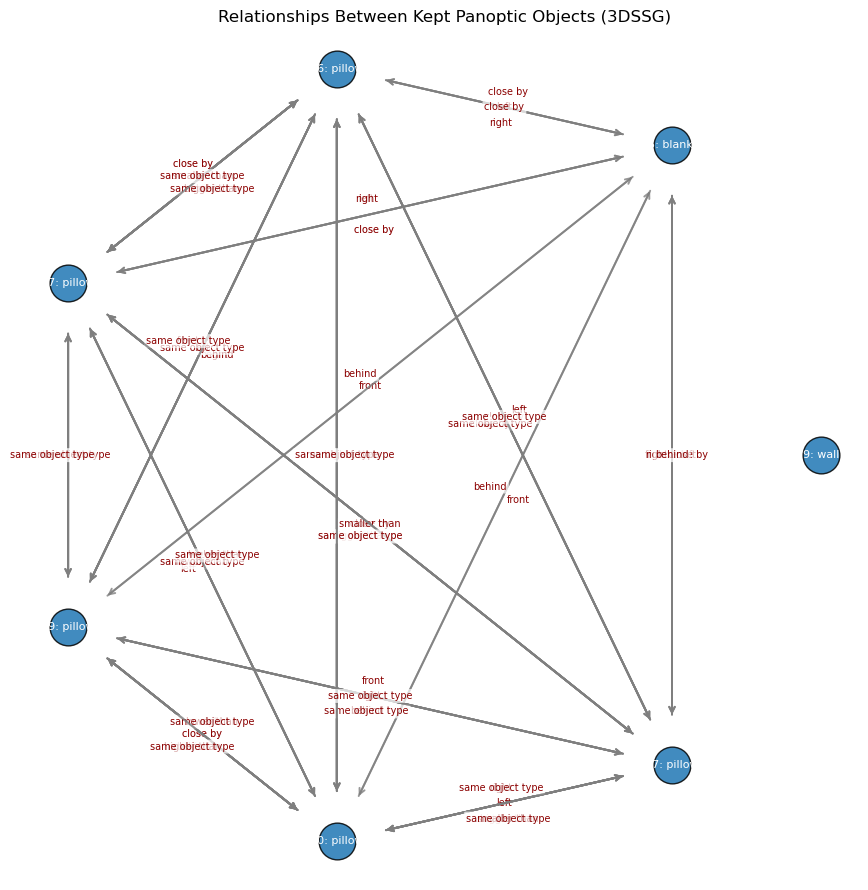

Relationships:
25:blanket --[6:close by]--> 26:pillow
25:blanket --[2:left]--> 26:pillow
25:blanket --[6:close by]--> 27:pillow
25:blanket --[2:left]--> 27:pillow
25:blanket --[4:front]--> 29:pillow
25:blanket --[4:front]--> 30:pillow
25:blanket --[4:front]--> 47:pillow
25:blanket --[6:close by]--> 47:pillow
25:blanket --[2:left]--> 47:pillow
26:pillow --[3:right]--> 25:blanket
26:pillow --[6:close by]--> 25:blanket
26:pillow --[4:front]--> 27:pillow
26:pillow --[6:close by]--> 27:pillow
26:pillow --[2:left]--> 27:pillow
26:pillow --[3:right]--> 29:pillow
26:pillow --[4:front]--> 29:pillow
26:pillow --[3:right]--> 30:pillow
26:pillow --[4:front]--> 30:pillow
26:pillow --[3:right]--> 47:pillow
26:pillow --[6:close by]--> 47:pillow
27:pillow --[3:right]--> 25:blanket
27:pillow --[6:close by]--> 25:blanket
27:pillow --[3:right]--> 26:pillow
27:pillow --[6:close by]--> 26:pillow
27:pillow --[5:behind]--> 26:pillow
27:pillow --[3:right]--> 29:pillow
27:pillow --[3:right]--> 30:pillow
27:pil

In [3]:
import json
from pathlib import Path

# Build relationship graph for kept panoptic objects using frame visibility + 3DSSG relationships.
scan_id = Path(image_path).parents[1].name
visibility_path = image_path.replace(".color.jpg", ".visibility.txt")
objects_json_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/objects.json"
relationships_json_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.json"
relationship_names_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.json"

kept_rendered_ids = {
    int(match_info["rendered_instance_id"])
    for match_info in best_match_for_panoptic.values()
}

visible_object_ids = set()
if os.path.exists(visibility_path):
    with open(visibility_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            try:
                visible_object_ids.add(int(parts[0]))
            except ValueError:
                continue

# Prefer objects visible in this frame; fallback to all kept objects if visibility is missing/empty.
if len(visible_object_ids) > 0:
    candidate_object_ids = kept_rendered_ids.intersection(visible_object_ids)
else:
    candidate_object_ids = set(kept_rendered_ids)

if len(candidate_object_ids) == 0:
    print("No kept rendered objects are visible in this frame according to visibility.txt")
else:
    with open(relationship_names_path, "r", encoding="utf-8") as f:
        relationship_names = [ln.strip() for ln in f if ln.strip()]

    with open(objects_json_path, "r", encoding="utf-8") as f:
        objects_data = json.load(f)

    with open(relationships_json_path, "r", encoding="utf-8") as f:
        relationships_data = json.load(f)

    scan_objects_entry = next(
        (entry for entry in objects_data.get("scans", []) if entry.get("scan") == scan_id),
        None,
    )
    object_name_by_id = {}
    if scan_objects_entry is not None:
        for obj in scan_objects_entry.get("objects", []):
            try:
                obj_id = int(obj.get("id"))
            except (TypeError, ValueError):
                continue
            object_name_by_id[obj_id] = obj.get("label", f"obj_{obj_id}")

    scan_relationships_entry = next(
        (entry for entry in relationships_data.get("scans", []) if entry.get("scan") == scan_id),
        None,
    )
    if scan_relationships_entry is None:
        raise ValueError(f"Scan {scan_id} not found in relationships.json")

    filtered_relationships = []
    for rel in scan_relationships_entry.get("relationships", []):
        if len(rel) < 3:
            continue
        try:
            src_id = int(rel[0])
            dst_id = int(rel[1])
            rel_id = int(rel[2])
        except (TypeError, ValueError):
            continue

        if src_id not in candidate_object_ids or dst_id not in candidate_object_ids:
            continue

        if 0 <= rel_id < len(relationship_names):
            rel_name = relationship_names[rel_id]
        elif len(rel) >= 4 and isinstance(rel[3], str):
            rel_name = rel[3]
        else:
            rel_name = f"rel_{rel_id}"

        filtered_relationships.append((src_id, dst_id, rel_id, rel_name))

    print(f"Scan: {scan_id}")
    print(f"Kept rendered instance IDs: {sorted(kept_rendered_ids)}")
    if len(visible_object_ids) > 0:
        print(f"Visible object IDs from frame: {sorted(visible_object_ids)}")
    print(f"Candidate object IDs used for relationships: {sorted(candidate_object_ids)}")
    print(f"Filtered relationships among kept objects: {len(filtered_relationships)}")

    # Keep all candidate objects as nodes, including isolated ones with no relations.
    unique_nodes = sorted(candidate_object_ids)
    n = len(unique_nodes)

    # Circular layout for a lightweight directed graph plot without extra dependencies.
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    radius = 1.0
    node_pos = {
        node_id: np.array([radius * np.cos(a), radius * np.sin(a)], dtype=np.float32)
        for node_id, a in zip(unique_nodes, angles)
    }

    fig, ax = plt.subplots(figsize=(11, 9))
    ax.set_title("Relationships Between Kept Panoptic Objects (3DSSG)")

    for node_id in unique_nodes:
        x, y = node_pos[node_id]
        ax.scatter(x, y, s=700, c="tab:blue", alpha=0.85, edgecolors="black")
        label_name = object_name_by_id.get(node_id, f"obj_{node_id}")
        ax.text(x, y, f"{node_id}: {label_name}", ha="center", va="center", color="white", fontsize=8)

    # Draw directed edges with relation labels.
    for idx, (src_id, dst_id, _, rel_name) in enumerate(filtered_relationships):
        src = node_pos[src_id]
        dst = node_pos[dst_id]
        vec = dst - src
        norm = np.linalg.norm(vec)
        if norm < 1e-8:
            continue
        unit = vec / norm

        start = src + unit * 0.12
        end = dst - unit * 0.12

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle="->", lw=1.4, color="tab:gray", alpha=0.8),
        )

        mid = (start + end) * 0.5
        perp = np.array([-unit[1], unit[0]], dtype=np.float32)
        offset = ((idx % 3) - 1) * 0.04
        text_pos = mid + perp * offset
        ax.text(
            text_pos[0],
            text_pos[1],
            rel_name,
            fontsize=7,
            color="darkred",
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
        )

    if len(filtered_relationships) == 0:
        ax.text(
            0.0,
            -1.25,
            "No relationship edges among current candidate nodes.",
            ha="center",
            va="center",
            fontsize=10,
            color="tab:red",
        )

    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print("Relationships:")
    if len(filtered_relationships) == 0:
        print("No relationship edges among candidate nodes.")
    else:
        for src_id, dst_id, rel_id, rel_name in filtered_relationships:
            src_name = object_name_by_id.get(src_id, f"obj_{src_id}")
            dst_name = object_name_by_id.get(dst_id, f"obj_{dst_id}")
            print(f"{src_id}:{src_name} --[{rel_id}:{rel_name}]--> {dst_id}:{dst_name}")

In [4]:
import torch
import torch.nn.functional as F

def extract_matched_queries_with_diagnostics(outputs, segments_info_subset, label_map=None):
    # 1. Access internal tensors
    queries = outputs.transformer_decoder_last_hidden_state.squeeze(0)  # [200, 256]
    logits = outputs.class_queries_logits.squeeze(0)                    # [200, 151]
    probs = F.softmax(logits, dim=-1)
    
    matched_data = []
    
    print(f"\n{'PAN ID':<8} | {'QUERY IDX':<10} | {'LABEL NAME':<15} | {'SCORE':<10} | {'STATUS':<10}")
    print("-" * 65)

    for info in segments_info_subset:
        seg_id = info['id']
        target_label = info['label_id']
        target_score = info['score']
        
        # Automatic matching logic
        found_idx = None
        for q_idx in range(probs.shape[0]):
            q_prob, q_label = torch.max(probs[q_idx], dim=-1)
            
            # Match by class ID and use a small tolerance for the float score
            if q_label == target_label and torch.abs(q_prob - target_score) < 1e-4:
                found_idx = q_idx
                break
        
        if found_idx is not None:
            class_name = label_map[target_label] if label_map else f"ID {target_label}"
            
            matched_data.append({
                "pan_id": seg_id,
                "query_idx": found_idx,
                "label": class_name,
                "vector": queries[found_idx]
            })
            
            print(f"{seg_id:<8} | {found_idx:<10} | {class_name:<15} | {target_score:<10.4f} | MATCHED ✅")
        else:
            print(f"{seg_id:<8} | {'N/A':<10} | {'Unknown':<15} | {target_score:<10.4f} | FAILED ❌")

    # Final feature matrix construction
    if matched_data:
        feature_matrix = torch.stack([m['vector'] for m in matched_data])
        print(f"\nSuccessfully built Feature Matrix: {feature_matrix.shape}")
        return matched_data, feature_matrix
    
    return None, None

# Usage: keep only IoU-matched panoptic instances from the previous cell.
kept_panoptic_ids_for_matching = {int(k) for k in best_match_for_panoptic.keys()}
segments_info_kept = [
    s for s in segments_info
    if int(s.get("id", -1)) in kept_panoptic_ids_for_matching
]
print(f"Matching on kept segments only: {len(segments_info_kept)} / {len(segments_info)}")

label_map = getattr(model.config, 'id2label', None)
matched_list, feature_matrix = extract_matched_queries_with_diagnostics(outputs, segments_info_kept, label_map)

Matching on kept segments only: 7 / 9

PAN ID   | QUERY IDX  | LABEL NAME      | SCORE      | STATUS    
-----------------------------------------------------------------
1        | 3          | bed             | 0.9873     | MATCHED ✅
2        | 33         | pillow          | 0.9981     | MATCHED ✅
3        | 54         | wall            | 0.9993     | MATCHED ✅
5        | 99         | pillow          | 0.9921     | MATCHED ✅
6        | 142        | cushion         | 0.9887     | MATCHED ✅
7        | 172        | pillow          | 0.9879     | MATCHED ✅
8        | 180        | pillow          | 0.9959     | MATCHED ✅

Successfully built Feature Matrix: torch.Size([7, 256])


In [5]:
# Keep only top-K queries after inference
K = 20

logits = outputs.class_queries_logits.squeeze(0)  # [num_queries, num_classes + 1]
probs = torch.softmax(logits, dim=-1)

# Ignore the last class because it is usually "no-object"
object_probs = probs[:, :-1]

# Confidence score for each query
query_scores, query_labels = object_probs.max(dim=1)

topk = torch.topk(query_scores, k=K)

topk_query_indices = topk.indices.cpu().tolist()
topk_query_scores = topk.values.cpu().tolist()
topk_query_labels = query_labels[topk.indices].cpu().tolist()

# Keep only top-K query embeddings
topk_queries = outputs.transformer_decoder_last_hidden_state.squeeze(0)[topk.indices]

print("Top-K query indices:")
print(topk_query_indices)

print("\nTop-K query details:")
for rank, (idx, score, label_id) in enumerate(
    zip(topk_query_indices, topk_query_scores, topk_query_labels), start=1
):
    label_name = model.config.id2label.get(int(label_id), "unknown")
    print(
        f"{rank:02d} | query={idx:03d} | score={score:.4f} | "
        f"label_id={label_id} | label={label_name}"
    )

print("\ntopk_queries shape:", tuple(topk_queries.shape))

Top-K query indices:
[54, 33, 180, 99, 142, 172, 3, 68, 195, 140, 58, 113, 86, 31, 175, 151, 169, 21, 122, 149]

Top-K query details:
01 | query=054 | score=0.9993 | label_id=0 | label=wall
02 | query=033 | score=0.9981 | label_id=57 | label=pillow
03 | query=180 | score=0.9959 | label_id=57 | label=pillow
04 | query=099 | score=0.9921 | label_id=57 | label=pillow
05 | query=142 | score=0.9887 | label_id=39 | label=cushion
06 | query=172 | score=0.9879 | label_id=57 | label=pillow
07 | query=003 | score=0.9873 | label_id=7 | label=bed 
08 | query=068 | score=0.9810 | label_id=134 | label=sconce
09 | query=195 | score=0.9301 | label_id=18 | label=curtain
10 | query=140 | score=0.8254 | label_id=3 | label=floor
11 | query=058 | score=0.7750 | label_id=3 | label=floor
12 | query=113 | score=0.7509 | label_id=15 | label=table
13 | query=086 | score=0.7213 | label_id=134 | label=sconce
14 | query=031 | score=0.6580 | label_id=36 | label=lamp
15 | query=175 | score=0.5872 | label_id=57 | lab

Plotting kept segments only: 7 / 9


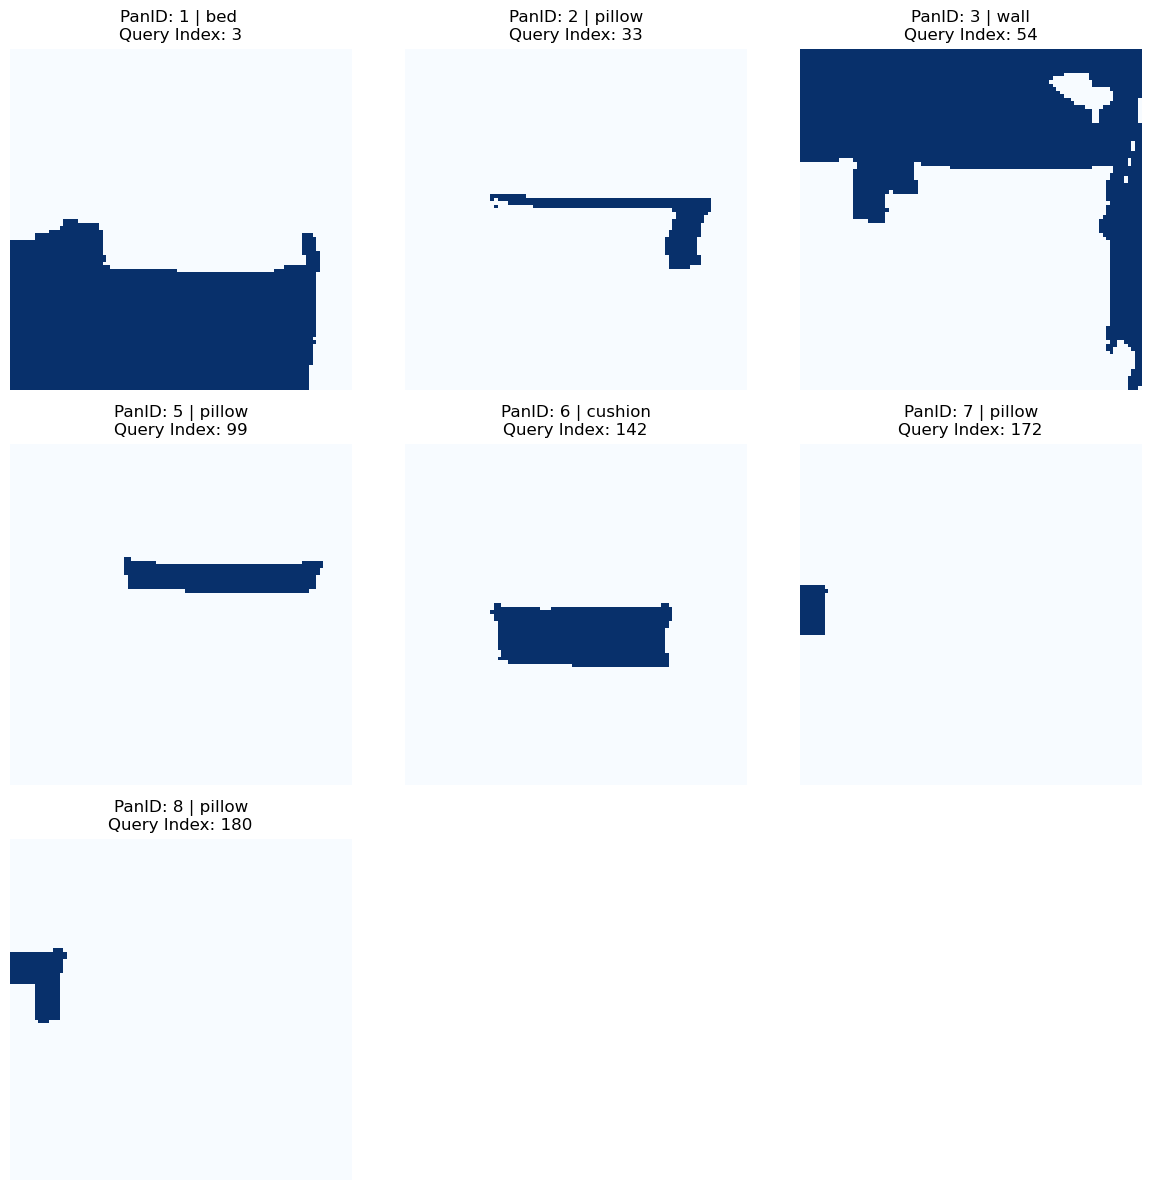

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def sync_and_plot(outputs, segments_info_subset, label_map=None):
    # 1. Extraction and Matching
    queries = outputs.transformer_decoder_last_hidden_state.squeeze(0)
    logits = outputs.class_queries_logits.squeeze(0)
    mask_logits = outputs.masks_queries_logits.squeeze(0)
    probs = F.softmax(logits, dim=-1)
    
    matched_list = []
    
    for info in segments_info_subset:
        target_label = info['label_id']
        target_score = info['score']
        
        found_idx = None
        for q_idx in range(probs.shape[0]):
            q_prob, q_label = torch.max(probs[q_idx], dim=-1)
            if q_label == target_label and torch.abs(q_prob - target_score) < 1e-4:
                found_idx = q_idx
                break
        
        if found_idx is not None:
            name = label_map[target_label] if label_map else f"ID {target_label}"
            matched_list.append({
                "pan_id": info['id'],
                "query_idx": found_idx,
                "label": name, # Fixed key name
                "mask": mask_logits[found_idx]
            })

    # 2. Plotting logic
    num_objs = len(matched_list)
    if num_objs == 0:
        print("No matches found to plot.")
        return

    cols = 3
    rows = (num_objs + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten() if num_objs > 1 else [axes]

    for i, item in enumerate(matched_list):
        # Convert raw logits to a binary mask prediction
        mask_prob = torch.sigmoid(item['mask']).detach().cpu().numpy()
        binary_mask = mask_prob > 0.5 
        
        axes[i].imshow(binary_mask, cmap='Blues')
        axes[i].set_title(f"PanID: {item['pan_id']} | {item['label']}\nQuery Index: {item['query_idx']}")
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Run it on IoU-kept panoptic segments only.
kept_panoptic_ids_for_matching = {int(k) for k in best_match_for_panoptic.keys()}
segments_info_kept = [
    s for s in segments_info
    if int(s.get("id", -1)) in kept_panoptic_ids_for_matching
]
print(f"Plotting kept segments only: {len(segments_info_kept)} / {len(segments_info)}")

label_map = getattr(model.config, 'id2label', None)
sync_and_plot(outputs, segments_info_kept, label_map)

## Build Relationship Training Sample for This Frame

This section exports one training sample from the current frame:
- `queries`: shape `[200, 256]` from Mask2Former decoder queries.
- `relationship_targets`: shape `[200, 200, num_relations]`, where entries are `1` when a relation exists between two matched queries, otherwise `0`.

The output is written beside the frame image as `frame-000XXX.relation.json`.

In [7]:
import json
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path

K = 20  # 🔥 number of queries to keep

def _extract_scan_relationships_entry(relationships_data, scan_id):
    scans = relationships_data.get("scans", [])
    return next((entry for entry in scans if entry.get("scan") == scan_id), None)

def _load_relation_names_from_txt(relationship_names_path):
    with open(relationship_names_path, "r", encoding="utf-8") as f:
        names = [line.strip() for line in f if line.strip()]
    if not names:
        raise ValueError(f"No relation names found in {relationship_names_path}")
    return names

def _map_panoptic_segment_to_query(outputs, segments_info_subset):
    logits = outputs.class_queries_logits.squeeze(0)
    probs = F.softmax(logits, dim=-1)
    used_query_indices = set()
    seg_id_to_query_idx = {}

    for seg in segments_info_subset:
        seg_id = int(seg["id"])
        label_id = int(seg["label_id"])
        score = float(seg["score"])
        label_scores = probs[:, label_id]

        found_idx = None
        candidates = torch.where(torch.abs(label_scores - score) < 1e-4)[0].tolist()
        for idx in candidates:
            if idx not in used_query_indices:
                found_idx = idx
                break

        if found_idx is None:
            ranked = torch.argsort(label_scores, descending=True).tolist()
            for idx in ranked:
                if idx not in used_query_indices:
                    found_idx = idx
                    break

        if found_idx is not None:
            used_query_indices.add(found_idx)
            seg_id_to_query_idx[seg_id] = int(found_idx)

    return seg_id_to_query_idx

# =========================
# 🔥 1) SELECT TOP-K QUERIES
# =========================
logits = outputs.class_queries_logits.squeeze(0)
probs = F.softmax(logits, dim=-1)

scores = probs[:, :-1].max(dim=1).values  # ignore "no-object"
topk = torch.topk(scores, K)

topk_indices = topk.indices.tolist()
old_to_new = {old: new for new, old in enumerate(topk_indices)}

queries_tensor_full = outputs.transformer_decoder_last_hidden_state.squeeze(0).detach().cpu()
queries_tensor = queries_tensor_full[topk_indices]

num_queries = K
hidden_dim = int(queries_tensor.shape[1])

# =========================
# 2) FILTER SEGMENTS
# =========================
kept_panoptic_ids_for_training = {int(k) for k in best_match_for_panoptic.keys()}
segments_info_kept = [
    s for s in segments_info
    if int(s.get("id", -1)) in kept_panoptic_ids_for_training
]

seg_id_to_query_idx_full = _map_panoptic_segment_to_query(outputs, segments_info_kept)

# 🔥 keep only top-K mapped queries
seg_id_to_query_idx = {
    seg_id: old_to_new[q_idx]
    for seg_id, q_idx in seg_id_to_query_idx_full.items()
    if q_idx in old_to_new
}

# =========================
# 3) FILTER OBJECT MATCHING
# =========================
rendered_to_panoptic = {}
for pan_id, info in best_match_for_panoptic.items():
    pan_id = int(pan_id)
    rend_id = int(info["rendered_instance_id"])
    iou = float(info["iou"])

    if pan_id not in seg_id_to_query_idx:
        continue  # 🔥 remove if query not in top-K

    if rend_id not in rendered_to_panoptic or iou > rendered_to_panoptic[rend_id]["iou"]:
        rendered_to_panoptic[rend_id] = {"pan_id": pan_id, "iou": iou}

kept_rendered_ids_for_training = set(rendered_to_panoptic.keys())

# =========================
# 4) LOAD RELATIONS
# =========================
scan_id = Path(image_path).parents[1].name

with open(relationships_json_path, "r", encoding="utf-8") as f:
    relationships_data = json.load(f)

scan_relationships_entry = _extract_scan_relationships_entry(relationships_data, scan_id)
if scan_relationships_entry is None:
    raise ValueError(f"Scan {scan_id} not found")

relationship_names_path = str(Path(relationships_json_path).with_name("relationships.txt"))
relation_names = _load_relation_names_from_txt(relationship_names_path)
num_relations = len(relation_names)

rel_id_to_index = {i: i for i in range(num_relations)}

# =========================
# 🔥 5) SMALL TARGET MATRIX
# =========================
relationship_targets = np.zeros((num_queries, num_queries, num_relations), dtype=np.uint8)

used_edges = 0
skipped_non_kept_objects = 0
skipped_unmapped = 0
skipped_rel_out_of_range = 0

for rel in scan_relationships_entry.get("relationships", []):
    if not isinstance(rel, (list, tuple)) or len(rel) < 3:
        continue

    try:
        src_rendered_id = int(rel[0])
        dst_rendered_id = int(rel[1])
        dataset_rel_id = int(rel[2])
    except:
        continue

    if dataset_rel_id not in rel_id_to_index:
        skipped_rel_out_of_range += 1
        continue

    if (
        src_rendered_id not in kept_rendered_ids_for_training
        or dst_rendered_id not in kept_rendered_ids_for_training
    ):
        skipped_non_kept_objects += 1
        continue

    src_info = rendered_to_panoptic.get(src_rendered_id)
    dst_info = rendered_to_panoptic.get(dst_rendered_id)

    if src_info is None or dst_info is None:
        skipped_unmapped += 1
        continue

    src_pan_id = int(src_info["pan_id"])
    dst_pan_id = int(dst_info["pan_id"])

    src_q = seg_id_to_query_idx.get(src_pan_id)
    dst_q = seg_id_to_query_idx.get(dst_pan_id)

    if src_q is None or dst_q is None:
        skipped_unmapped += 1
        continue

    rel_idx = rel_id_to_index[dataset_rel_id]
    relationship_targets[src_q, dst_q, rel_idx] = 1
    used_edges += 1

# =========================
# 6) SAVE
# =========================
output_path = image_path.replace(".color.jpg", ".relation.json")

sample = {
    "frame_id": Path(image_path).name.replace(".color.jpg", ""),
    "scan_id": scan_id,
    "image_path": image_path,
    "query_shape": [num_queries, hidden_dim],
    "relationship_shape": [num_queries, num_queries, num_relations],
    "relation_names": relation_names,
    "queries": queries_tensor.numpy().tolist(),
    "relationship_targets": relationship_targets.tolist(),
    "metadata": {
        "topk_indices": topk_indices,  # 🔥 important for debugging
        "num_positive_edges": int(relationship_targets.sum()),
        "num_relationship_records_used": used_edges,
    },
}

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(sample, f)

print(f"Saved training sample: {output_path}")
print(f"queries shape: {sample['query_shape']}")
print(f"relationship_targets shape: {sample['relationship_shape']}")
print(f"Top-K indices: {topk_indices}")

Saved training sample: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000000.relation.json
queries shape: [20, 256]
relationship_targets shape: [20, 20, 41]
Top-K indices: [54, 33, 180, 99, 142, 172, 3, 68, 195, 140, 58, 113, 86, 31, 175, 151, 169, 21, 122, 149]


## Mask2Former + Relationship Branch (Frozen Backbone)

This section defines a model that freezes Mask2Former and trains only a relationship module on top of decoder queries.
It then runs a short sanity-check optimization loop on the current frame and relation targets.

In [8]:
import json
from pathlib import Path
import torch
import torch.nn as nn

# =========================
# Load saved relation sample
# =========================
required_vars = ["image_path"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites: {missing}")

relation_json_path = image_path.replace(".color.jpg", ".relation.json")

with open(relation_json_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

queries = torch.tensor(sample["queries"], dtype=torch.float32)                 # [20, 256]
relationship_targets = torch.tensor(sample["relationship_targets"], dtype=torch.float32)  # [20, 20, R]

print("Loaded:", relation_json_path)
print("queries shape:", tuple(queries.shape))
print("targets shape:", tuple(relationship_targets.shape))

# =========================
# Relation-only model
# =========================
class RelationHead(nn.Module):
    def __init__(self, hidden_dim=256, num_rel_classes=41, nhead=8, num_rel_layers=3):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=512,
            batch_first=True,
        )

        self.rel_transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_rel_layers,
        )

        self.rel_predictor = nn.Sequential(
            nn.Linear(hidden_dim * 4, 512),
            nn.ReLU(),
            nn.Linear(512, num_rel_classes),
        )

    def forward(self, queries):
        # queries: [B, K, D]
        refined = self.rel_transformer(queries)

        bsz, k, d = refined.shape

        q_i = refined.unsqueeze(2).expand(bsz, k, k, d)
        q_j = refined.unsqueeze(1).expand(bsz, k, k, d)

        pair_features = torch.cat(
            [q_i, q_j, q_i - q_j, q_i * q_j],
            dim=-1,
        )

        rel_logits = self.rel_predictor(pair_features)  # [B, K, K, R]
        return rel_logits
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=0.95, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        prob = torch.sigmoid(logits)

        ce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )

        p_t = prob * targets + (1 - prob) * (1 - targets)

        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        loss = alpha_t * ((1 - p_t) ** self.gamma) * ce
        return loss.mean()
# =========================
# Setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

queries = queries.unsqueeze(0).to(device)                      # [1, 20, 256]
target_rel = relationship_targets.unsqueeze(0).to(device)      # [1, 20, 20, R]

_, TOP_K, hidden_dim = queries.shape
num_rel_classes = target_rel.shape[-1]

model = RelationHead(
    hidden_dim=hidden_dim,
    num_rel_classes=num_rel_classes,
    nhead=8,
    num_rel_layers=3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
num_pos = target_rel.sum()
num_total = target_rel.numel()
num_neg = num_total - num_pos

pos_weight = (num_neg / (num_pos + 1e-8)) ** 0.5

criterion = WeightedFocalLoss(alpha=0.95, gamma=2.0)

print("pos_weight:", float(pos_weight))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# =========================
# Sanity-check training loop
# =========================
model.train()

steps = 100

for step in range(1, steps + 1):
    optimizer.zero_grad()

    rel_logits = model(queries)

    if rel_logits.shape != target_rel.shape:
        raise RuntimeError(
            f"Shape mismatch: rel_logits={tuple(rel_logits.shape)} "
            f"vs target={tuple(target_rel.shape)}"
        )

    loss = criterion(rel_logits, target_rel)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred_prob = torch.sigmoid(rel_logits)

        pos_scores = pred_prob[target_rel == 1]
        neg_scores = pred_prob[target_rel == 0]

        print("Pos scores: min/max/mean =", pos_scores.min().item(), pos_scores.max().item(), pos_scores.mean().item())
        print("Neg scores: min/max/mean =", neg_scores.min().item(), neg_scores.max().item(), neg_scores.mean().item())
        pred_prob = torch.sigmoid(rel_logits)
        pred_bin = (pred_prob > 0.6).float()

        positives = target_rel.sum().item()
        pred_positives = pred_bin.sum().item()

        tp = ((pred_bin == 1) & (target_rel == 1)).sum().item()
        fp = ((pred_bin == 1) & (target_rel == 0)).sum().item()
        fn = ((pred_bin == 0) & (target_rel == 1)).sum().item()

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

    print(
        f"Step {step:03d}/{steps} | "
        f"loss={loss.item():.6f} | "
        f"pos={positives:.0f} | "
        f"pred_pos={pred_positives:.0f} | "
        f"P={precision:.3f} | R={recall:.3f} | F1={f1:.3f}"
    )

print("Relation-only sanity-check training loop finished.")

Loaded: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000000.relation.json
queries shape: (20, 256)
targets shape: (20, 20, 41)
Total params: 2,127,145
Trainable params: 2,127,145
pos_weight: 13.313935279846191
Pos scores: min/max/mean = 0.4003467559814453 0.6748321056365967 0.544254720211029
Neg scores: min/max/mean = 0.2865549623966217 0.7576024532318115 0.498241662979126
Step 001/100 | loss=0.009940 | pos=92 | pred_pos=939 | P=0.024 | R=0.250 | F1=0.045
Pos scores: min/max/mean = 0.4057777523994446 0.6627287268638611 0.5357769131660461
Neg scores: min/max/mean = 0.2665327191352844 0.7339655160903931 0.47975438833236694
Step 002/100 | loss=0.008814 | pos=92 | pred_pos=441 | P=0.050 | R=0.239 | F1=0.083
Pos scores: min/max/mean = 0.41288134455680847 0.6520386934280396 0.5356175303459167
Neg scores: min/max/mean = 0.28025203943252563 0.7282834649085999 0.4605662226676941
Step 003/100 | loss=0.007762 | pos=92 | pr

Loaded: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000000.relation.json
queries shape: (1, 20, 256)
Top-K old query indices: [54, 33, 180, 99, 142, 172, 3, 68, 195, 140, 58, 113, 86, 31, 175, 151, 169, 21, 122, 149]
rel_probs shape: (20, 20, 41)


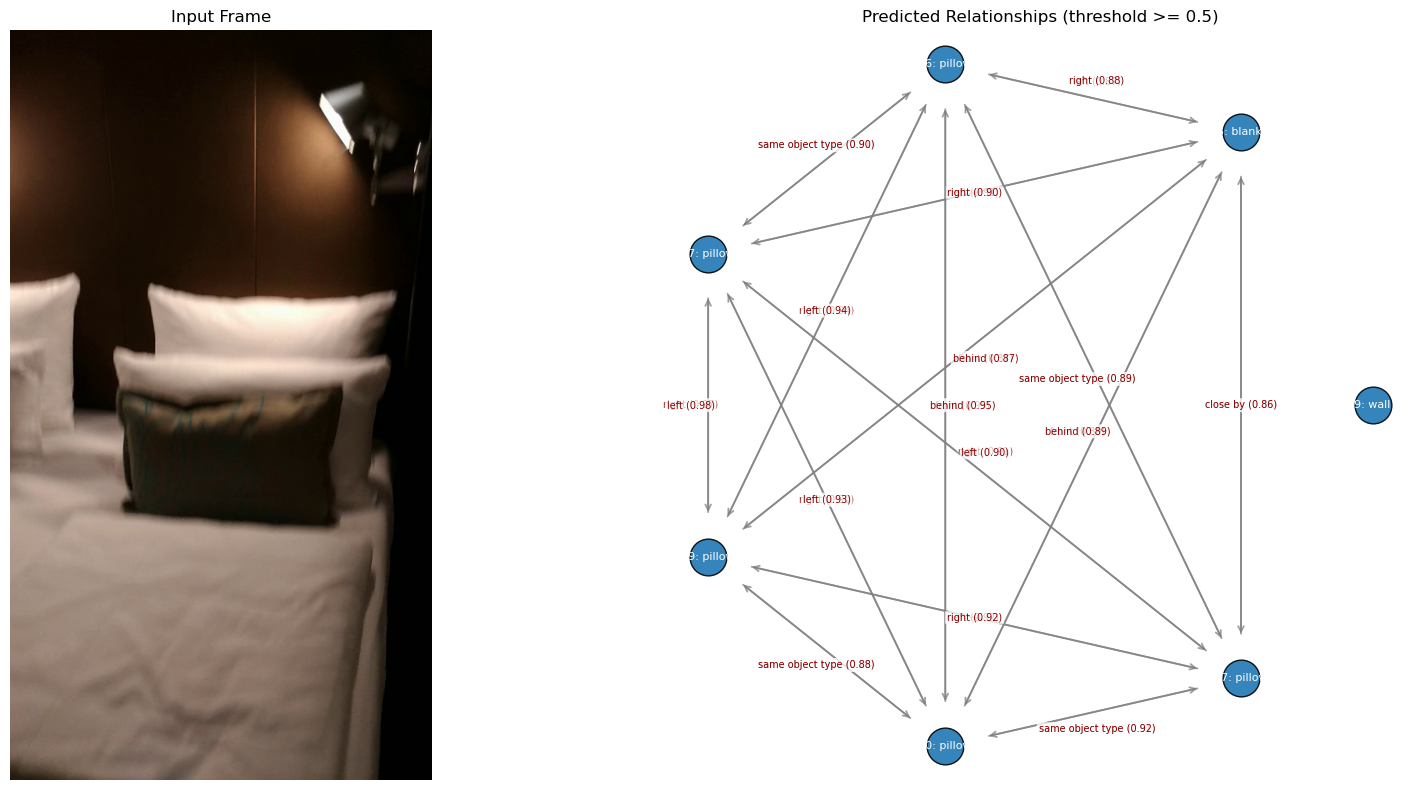

Candidate nodes before top-K filtering: 7
Candidate nodes after top-K filtering: 7
Edge selection mode: threshold >= 0.5
Selected predicted edges: 30
25:blanket --[2:left (0.874)]--> 26:pillow
25:blanket --[2:left (0.915)]--> 27:pillow
25:blanket --[4:front (0.866)]--> 29:pillow
25:blanket --[4:front (0.888)]--> 30:pillow
25:blanket --[6:close by (0.850)]--> 47:pillow
26:pillow --[3:right (0.880)]--> 25:blanket
26:pillow --[32:same object type (0.907)]--> 27:pillow
26:pillow --[3:right (0.937)]--> 29:pillow
26:pillow --[4:front (0.948)]--> 30:pillow
26:pillow --[32:same object type (0.881)]--> 47:pillow
27:pillow --[3:right (0.902)]--> 25:blanket
27:pillow --[32:same object type (0.903)]--> 26:pillow
27:pillow --[3:right (0.971)]--> 29:pillow
27:pillow --[3:right (0.903)]--> 30:pillow
27:pillow --[3:right (0.913)]--> 47:pillow
29:pillow --[5:behind (0.871)]--> 25:blanket
29:pillow --[2:left (0.939)]--> 26:pillow
29:pillow --[2:left (0.977)]--> 27:pillow
29:pillow --[32:same object type

In [9]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

required_vars = ["model", "image", "image_path", "best_match_for_panoptic"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites: {missing}. Run previous cells first.")

device = next(model.parameters()).device
model.eval()

# =========================
# Load saved relation JSON
# =========================
relation_json_path = image_path.replace(".color.jpg", ".relation.json")

with open(relation_json_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

queries = torch.tensor(sample["queries"], dtype=torch.float32).unsqueeze(0).to(device)
topk_indices = sample["metadata"]["topk_indices"]

old_query_to_topk = {
    int(old_q): int(new_q)
    for new_q, old_q in enumerate(topk_indices)
}

print("Loaded:", relation_json_path)
print("queries shape:", tuple(queries.shape))
print("Top-K old query indices:", topk_indices)

# =========================
# Relation inference only
# =========================
with torch.inference_mode():
    rel_logits = model(queries)  # [1, 20, 20, R]
    rel_probs = torch.sigmoid(rel_logits)[0].detach().cpu().numpy()

print("rel_probs shape:", rel_probs.shape)

# =========================
# Load names
# =========================
scan_id = Path(image_path).parents[1].name

objects_json_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/objects.json"
relationships_json_path = "/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.json"
relation_names_path = str(Path(relationships_json_path).with_name("relationships.txt"))

with open(relation_names_path, "r", encoding="utf-8") as f:
    relation_names = [line.strip() for line in f if line.strip()]

with open(objects_json_path, "r", encoding="utf-8") as f:
    objects_data = json.load(f)

scan_objects_entry = next(
    (entry for entry in objects_data.get("scans", []) if entry.get("scan") == scan_id),
    None,
)

object_name_by_id = {}
if scan_objects_entry is not None:
    for obj in scan_objects_entry.get("objects", []):
        try:
            obj_id = int(obj.get("id"))
        except (TypeError, ValueError):
            continue
        object_name_by_id[obj_id] = obj.get("label", f"obj_{obj_id}")

# =========================
# Candidate objects
# =========================
kept_rendered_ids = {
    int(match_info["rendered_instance_id"])
    for match_info in best_match_for_panoptic.values()
}

visibility_path = image_path.replace(".color.jpg", ".visibility.txt")
visible_object_ids = set()

if Path(visibility_path).exists():
    with open(visibility_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            try:
                visible_object_ids.add(int(parts[0]))
            except ValueError:
                continue

if len(visible_object_ids) > 0:
    candidate_object_ids = kept_rendered_ids.intersection(visible_object_ids)
else:
    candidate_object_ids = set(kept_rendered_ids)

# =========================
# rendered object -> top-K query
# =========================
rendered_to_panoptic = {
    int(info["rendered_instance_id"]): int(pan_id)
    for pan_id, info in best_match_for_panoptic.items()
}

if "matched_list" in globals() and matched_list is not None:
    panoptic_to_query = {
        int(item["pan_id"]): int(item["query_idx"])
        for item in matched_list
    }
else:
    panoptic_to_query = {}

rendered_to_query = {}

for rid in candidate_object_ids:
    pan_id = rendered_to_panoptic.get(int(rid))
    if pan_id is None:
        continue

    old_qid = panoptic_to_query.get(int(pan_id))
    if old_qid is None:
        continue

    new_qid = old_query_to_topk.get(int(old_qid))
    if new_qid is not None:
        rendered_to_query[int(rid)] = int(new_qid)

sorted_nodes = sorted(rendered_to_query.keys())

# =========================
# Predict relation edges
# =========================
relationship_threshold = 0.5
top_k_fallback = 10

all_scored_edges = []

for src_id in sorted_nodes:
    src_q = rendered_to_query.get(int(src_id))
    if src_q is None:
        continue

    for dst_id in sorted_nodes:
        if src_id == dst_id:
            continue

        dst_q = rendered_to_query.get(int(dst_id))
        if dst_q is None:
            continue

        scores = rel_probs[src_q, dst_q]
        rel_id = int(np.argmax(scores))
        rel_score = float(scores[rel_id])

        rel_name = (
            relation_names[rel_id]
            if 0 <= rel_id < len(relation_names)
            else f"rel_{rel_id}"
        )

        all_scored_edges.append(
            (int(src_id), int(dst_id), rel_id, rel_name, rel_score)
        )

predicted_relationships = [
    edge for edge in all_scored_edges
    if edge[4] >= relationship_threshold
]

selection_mode = f"threshold >= {relationship_threshold}"

if len(predicted_relationships) == 0 and len(all_scored_edges) > 0:
    predicted_relationships = sorted(
        all_scored_edges,
        key=lambda x: x[4],
        reverse=True,
    )[:top_k_fallback]

    selection_mode = f"top-{len(predicted_relationships)} fallback"

# =========================
# Visualization
# =========================
if len(sorted_nodes) == 0:
    print("No candidate objects survived top-K query filtering.")
else:
    n = len(sorted_nodes)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    radius = 1.0

    node_pos = {
        node_id: np.array(
            [radius * np.cos(angle), radius * np.sin(angle)],
            dtype=np.float32,
        )
        for node_id, angle in zip(sorted_nodes, angles)
    }

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].imshow(image)
    axes[0].set_title("Input Frame")
    axes[0].axis("off")

    ax = axes[1]
    ax.set_title(f"Predicted Relationships ({selection_mode})")

    for node_id in sorted_nodes:
        x, y = node_pos[node_id]
        label_name = object_name_by_id.get(node_id, f"obj_{node_id}")

        ax.scatter(
            x,
            y,
            s=700,
            c="tab:blue",
            alpha=0.9,
            edgecolors="black",
        )

        ax.text(
            x,
            y,
            f"{node_id}: {label_name}",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
        )

    for idx, (src_id, dst_id, _, rel_name, rel_score) in enumerate(predicted_relationships):
        src = node_pos[src_id]
        dst = node_pos[dst_id]

        vec = dst - src
        norm = np.linalg.norm(vec)
        if norm < 1e-8:
            continue

        unit = vec / norm
        start = src + unit * 0.12
        end = dst - unit * 0.12

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(
                arrowstyle="->",
                lw=1.3,
                color="tab:gray",
                alpha=0.75,
            ),
        )

        mid = (start + end) * 0.5
        perp = np.array([-unit[1], unit[0]], dtype=np.float32)
        offset = ((idx % 3) - 1) * 0.05
        text_pos = mid + perp * offset

        ax.text(
            text_pos[0],
            text_pos[1],
            f"{rel_name} ({rel_score:.2f})",
            fontsize=7,
            color="darkred",
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.75,
                edgecolor="none",
            ),
        )

    if len(predicted_relationships) == 0:
        ax.text(
            0.0,
            0.0,
            "No predicted edges available",
            ha="center",
            va="center",
            fontsize=10,
            color="tab:red",
        )

    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# =========================
# Print results
# =========================
print(f"Candidate nodes before top-K filtering: {len(candidate_object_ids)}")
print(f"Candidate nodes after top-K filtering: {len(sorted_nodes)}")
print(f"Edge selection mode: {selection_mode}")
print(f"Selected predicted edges: {len(predicted_relationships)}")

for src_id, dst_id, rel_id, rel_name, rel_score in predicted_relationships[:50]:
    src_name = object_name_by_id.get(src_id, f"obj_{src_id}")
    dst_name = object_name_by_id.get(dst_id, f"obj_{dst_id}")

    print(
        f"{src_id}:{src_name} "
        f"--[{rel_id}:{rel_name} ({rel_score:.3f})]--> "
        f"{dst_id}:{dst_name}"
    )

## Build Relation JSON Dataset For All Frames

This section iterates over every frame in one sequence and writes one `.relation.json` file per frame for training.

In [11]:
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
from tqdm import tqdm

# -------- Config --------
scans_root = Path("/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans")

relationships_json_path = Path(
    "/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.json"
)
relationship_names_path = relationships_json_path.with_name("relationships.txt")

model_name = checkpoint if "checkpoint" in globals() else "facebook/mask2former-swin-large-ade-panoptic"

TOP_K = 20
iou_threshold = 0.3
use_visibility_filter_for_targets = False
max_scans = None      # set int for debug
max_frames_per_scan = None
overwrite_existing = True
# -----------------------

if not scans_root.exists():
    raise FileNotFoundError(f"Scans root not found: {scans_root}")
if not relationships_json_path.exists():
    raise FileNotFoundError(f"Missing relationships.json: {relationships_json_path}")
if not relationship_names_path.exists():
    raise FileNotFoundError(f"Missing relationships.txt: {relationship_names_path}")

with open(relationships_json_path, "r", encoding="utf-8") as f:
    relationships_data = json.load(f)

with open(relationship_names_path, "r", encoding="utf-8") as f:
    relation_names = [line.strip() for line in f if line.strip()]

relationships_by_scan = {
    entry.get("scan"): entry
    for entry in relationships_data.get("scans", [])
    if entry.get("scan") is not None
}


def align_to_reference_orientation(img, reference_size):
    if img.size == reference_size:
        return img

    for angle in (-90, 90, 180):
        candidate = img.rotate(angle, expand=True)
        if candidate.size == reference_size:
            return candidate

    return img


def decode_rendered_instances(instances_img):
    arr = np.array(instances_img, dtype=np.uint8)

    if arr.ndim == 3:
        if (
            np.array_equal(arr[..., 0], arr[..., 1])
            and np.array_equal(arr[..., 1], arr[..., 2])
        ):
            return arr[..., 0].astype(np.int32)

        return (
            arr[..., 0].astype(np.int32)
            + (arr[..., 1].astype(np.int32) << 8)
            + (arr[..., 2].astype(np.int32) << 16)
        )

    return arr.astype(np.int32)


def map_panoptic_segment_to_query(outputs, segments_info_subset):
    logits = outputs.class_queries_logits.squeeze(0)
    probs = F.softmax(logits, dim=-1)

    used_query_indices = set()
    seg_id_to_query_idx = {}

    for seg in segments_info_subset:
        seg_id = int(seg["id"])
        label_id = int(seg["label_id"])
        score = float(seg["score"])

        label_scores = probs[:, label_id]

        found_idx = None

        candidates = torch.where(torch.abs(label_scores - score) < 1e-4)[0].tolist()
        for idx in candidates:
            if idx not in used_query_indices:
                found_idx = idx
                break

        if found_idx is None:
            ranked = torch.argsort(label_scores, descending=True).tolist()
            for idx in ranked:
                if idx not in used_query_indices:
                    found_idx = idx
                    break

        if found_idx is not None:
            used_query_indices.add(found_idx)
            seg_id_to_query_idx[seg_id] = int(found_idx)

    return seg_id_to_query_idx


def best_iou_matches_vectorized(
    predicted_panoptic_map,
    rendered_instance_ids,
    panoptic_ids,
    rendered_ids,
    threshold,
):
    if len(panoptic_ids) == 0 or len(rendered_ids) == 0:
        return {}

    panoptic_ids_arr = np.asarray(panoptic_ids, dtype=np.int64)
    rendered_ids_arr = np.asarray(rendered_ids, dtype=np.int64)

    pan_idx_map = {int(pid): i for i, pid in enumerate(panoptic_ids_arr.tolist())}
    rend_idx_map = {int(rid): i for i, rid in enumerate(rendered_ids_arr.tolist())}

    pan_areas = np.array(
        [(predicted_panoptic_map == pid).sum() for pid in panoptic_ids_arr],
        dtype=np.int64,
    )

    rend_areas = np.array(
        [(rendered_instance_ids == rid).sum() for rid in rendered_ids_arr],
        dtype=np.int64,
    )

    valid_pan = np.isin(predicted_panoptic_map, panoptic_ids_arr)
    valid_rend = np.isin(rendered_instance_ids, rendered_ids_arr)
    valid = valid_pan & valid_rend

    pan_vals = predicted_panoptic_map[valid].astype(np.int64)
    rend_vals = rendered_instance_ids[valid].astype(np.int64)

    if pan_vals.size == 0:
        return {}

    pan_idx = np.array([pan_idx_map[int(v)] for v in pan_vals], dtype=np.int64)
    rend_idx = np.array([rend_idx_map[int(v)] for v in rend_vals], dtype=np.int64)

    intersections = np.zeros(
        (len(panoptic_ids_arr), len(rendered_ids_arr)),
        dtype=np.int64,
    )

    np.add.at(intersections, (pan_idx, rend_idx), 1)

    unions = pan_areas[:, None] + rend_areas[None, :] - intersections
    iou_matrix = intersections / np.maximum(unions, 1)

    best_rend_indices = np.argmax(iou_matrix, axis=1)
    best_ious = iou_matrix[np.arange(iou_matrix.shape[0]), best_rend_indices]

    best_match_for_panoptic = {}

    for i, pan_id in enumerate(panoptic_ids_arr.tolist()):
        best_iou = float(best_ious[i])

        if best_iou > threshold:
            best_rid = int(rendered_ids_arr[int(best_rend_indices[i])])
            best_match_for_panoptic[int(pan_id)] = {
                "rendered_instance_id": best_rid,
                "iou": best_iou,
            }

    return best_match_for_panoptic


def select_topk_queries(outputs, top_k):
    logits = outputs.class_queries_logits.squeeze(0)
    probs = F.softmax(logits, dim=-1)

    scores = probs[:, :-1].max(dim=1).values

    k = min(top_k, scores.shape[0])
    topk = torch.topk(scores, k=k)

    topk_indices = topk.indices.detach().cpu().tolist()
    topk_scores = topk.values.detach().cpu().tolist()

    old_to_new = {
        int(old_idx): int(new_idx)
        for new_idx, old_idx in enumerate(topk_indices)
    }

    queries_full = outputs.transformer_decoder_last_hidden_state.squeeze(0).detach().cpu()
    queries_topk = queries_full[topk_indices]

    return queries_topk, topk_indices, topk_scores, old_to_new


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor_ds = AutoImageProcessor.from_pretrained(model_name)
model_ds = Mask2FormerForUniversalSegmentation.from_pretrained(model_name).to(device)
model_ds.eval()

scan_dirs = sorted([p for p in scans_root.iterdir() if p.is_dir()])

if max_scans is not None:
    scan_dirs = scan_dirs[:max_scans]

global_index = {
    "scans_root": str(scans_root),
    "top_k": TOP_K,
    "iou_threshold": iou_threshold,
    "use_visibility_filter_for_targets": use_visibility_filter_for_targets,
    "items": [],
}

total_generated = 0
total_skipped = 0
total_scans_done = 0

for scan_dir in tqdm(scan_dirs, desc="Scans"):
    scan_id = scan_dir.name
    sequence_dir = scan_dir / "sequence"

    if not sequence_dir.exists():
        total_skipped += 1
        continue

    scan_relationships_entry = relationships_by_scan.get(scan_id)
    if scan_relationships_entry is None:
        print(f"[skip scan] {scan_id}: not found in relationships.json")
        total_skipped += 1
        continue

    all_color_frames = sorted(sequence_dir.glob("frame-*.color.jpg"))
    frame_paths = [p for p in all_color_frames if ".rendered." not in p.name]

    if max_frames_per_scan is not None:
        frame_paths = frame_paths[:max_frames_per_scan]

    if len(frame_paths) == 0:
        print(f"[skip scan] {scan_id}: no frames")
        total_skipped += 1
        continue

    generated = 0
    skipped = 0
    dataset_index = []

    for frame_path in tqdm(frame_paths, desc=f"{scan_id}", leave=False):
        out_path = Path(str(frame_path).replace(".color.jpg", ".relation.json"))

        if out_path.exists() and not overwrite_existing:
            skipped += 1
            continue

        instances_path = Path(str(frame_path).replace(".color.jpg", ".rendered.instances.png"))
        visibility_path = Path(str(frame_path).replace(".color.jpg", ".visibility.txt"))

        if not instances_path.exists():
            skipped += 1
            continue

        try:
            image = Image.open(frame_path).convert("RGB").rotate(-90, expand=True)

            rendered_instances = Image.open(instances_path).convert("RGB")
            rendered_instances = align_to_reference_orientation(rendered_instances, image.size)
            rendered_instance_ids = decode_rendered_instances(rendered_instances)

            inputs_ds = processor_ds(images=image, return_tensors="pt")
            inputs_ds = {k: v.to(device) for k, v in inputs_ds.items()}

            with torch.inference_mode():
                outputs_ds = model_ds(**inputs_ds)

                panoptic = processor_ds.post_process_panoptic_segmentation(
                    outputs_ds,
                    target_sizes=[image.size[::-1]],
                    threshold=0.3,
                    mask_threshold=0.3,
                    overlap_mask_area_threshold=0.7,
                )[0]

            predicted_panoptic_map = panoptic["segmentation"].cpu().numpy()
            segments_info = panoptic["segments_info"]

            panoptic_ids = [
                int(x)
                for x in np.unique(predicted_panoptic_map)
                if int(x) != 0
            ]

            rendered_ids = [
                int(x)
                for x in np.unique(rendered_instance_ids)
                if int(x) != 0
            ]

            best_match_for_panoptic = best_iou_matches_vectorized(
                predicted_panoptic_map=predicted_panoptic_map,
                rendered_instance_ids=rendered_instance_ids,
                panoptic_ids=panoptic_ids,
                rendered_ids=rendered_ids,
                threshold=iou_threshold,
            )

            kept_panoptic_ids = set(best_match_for_panoptic.keys())

            segments_info_kept = [
                s for s in segments_info
                if int(s.get("id", -1)) in kept_panoptic_ids
            ]

            seg_id_to_query_idx_full = map_panoptic_segment_to_query(
                outputs_ds,
                segments_info_kept,
            )

            queries_tensor, topk_indices, topk_scores, old_to_new = select_topk_queries(
                outputs_ds,
                TOP_K,
            )

            num_queries = int(queries_tensor.shape[0])
            hidden_dim = int(queries_tensor.shape[1])
            num_relations = len(relation_names)

            seg_id_to_query_idx = {
                int(seg_id): int(old_to_new[old_q])
                for seg_id, old_q in seg_id_to_query_idx_full.items()
                if int(old_q) in old_to_new
            }

            rendered_to_panoptic = {}

            for pan_id, match_info in best_match_for_panoptic.items():
                pan_id = int(pan_id)

                if pan_id not in seg_id_to_query_idx:
                    continue

                rendered_id = int(match_info["rendered_instance_id"])
                iou = float(match_info["iou"])

                if (
                    rendered_id not in rendered_to_panoptic
                    or iou > rendered_to_panoptic[rendered_id]["iou"]
                ):
                    rendered_to_panoptic[rendered_id] = {
                        "pan_id": pan_id,
                        "iou": iou,
                    }

            kept_rendered_ids = set(rendered_to_panoptic.keys())

            visible_object_ids = set()

            if visibility_path.exists():
                with open(visibility_path, "r", encoding="utf-8") as f:
                    for line in f:
                        parts = line.strip().split()

                        if not parts:
                            continue

                        try:
                            visible_object_ids.add(int(parts[0]))
                        except ValueError:
                            pass

            if use_visibility_filter_for_targets and len(visible_object_ids) > 0:
                candidate_rendered_ids = kept_rendered_ids.intersection(visible_object_ids)
            else:
                candidate_rendered_ids = set(kept_rendered_ids)

            relationship_targets = np.zeros(
                (num_queries, num_queries, num_relations),
                dtype=np.uint8,
            )

            used_edges = 0
            skipped_non_candidate = 0
            skipped_unmapped = 0
            skipped_rel_out_of_range = 0

            for rel in scan_relationships_entry.get("relationships", []):
                if not isinstance(rel, (list, tuple)) or len(rel) < 3:
                    continue

                try:
                    src_rendered_id = int(rel[0])
                    dst_rendered_id = int(rel[1])
                    rel_id = int(rel[2])
                except (TypeError, ValueError):
                    continue

                if rel_id < 0 or rel_id >= num_relations:
                    skipped_rel_out_of_range += 1
                    continue

                if (
                    src_rendered_id not in candidate_rendered_ids
                    or dst_rendered_id not in candidate_rendered_ids
                ):
                    skipped_non_candidate += 1
                    continue

                src_info = rendered_to_panoptic.get(src_rendered_id)
                dst_info = rendered_to_panoptic.get(dst_rendered_id)

                if src_info is None or dst_info is None:
                    skipped_unmapped += 1
                    continue

                src_pan = int(src_info["pan_id"])
                dst_pan = int(dst_info["pan_id"])

                src_q = seg_id_to_query_idx.get(src_pan)
                dst_q = seg_id_to_query_idx.get(dst_pan)

                if src_q is None or dst_q is None:
                    skipped_unmapped += 1
                    continue

                relationship_targets[src_q, dst_q, rel_id] = 1
                used_edges += 1

            sample = {
                "frame_id": frame_path.name.replace(".color.jpg", ""),
                "scan_id": scan_id,
                "image_path": str(frame_path),

                "query_shape": [num_queries, hidden_dim],
                "relationship_shape": [num_queries, num_queries, num_relations],

                "relation_names": relation_names,
                "relation_names_path": str(relationship_names_path),

                "queries": queries_tensor.numpy().tolist(),
                "relationship_targets": relationship_targets.tolist(),

                "metadata": {
                    "top_k": TOP_K,
                    "topk_indices": topk_indices,
                    "topk_scores": topk_scores,

                    "num_segments_info_total": len(segments_info),
                    "num_segments_info_kept_iou": len(segments_info_kept),
                    "num_segments_survived_topk": len(seg_id_to_query_idx),

                    "num_kept_rendered_ids": len(kept_rendered_ids),
                    "num_candidate_rendered_ids": len(candidate_rendered_ids),

                    "num_positive_edges": int(relationship_targets.sum()),
                    "num_relationship_records_used": used_edges,
                    "num_relationship_records_skipped_non_candidate": skipped_non_candidate,
                    "num_relationship_records_skipped_unmapped": skipped_unmapped,
                    "num_relationship_records_skipped_rel_out_of_range": skipped_rel_out_of_range,

                    "iou_threshold": iou_threshold,
                    "use_visibility_filter_for_targets": use_visibility_filter_for_targets,
                },
            }

            with open(out_path, "w", encoding="utf-8") as f:
                json.dump(sample, f)

            generated += 1
            total_generated += 1

            dataset_index.append({
                "frame": frame_path.name,
                "relation_json": out_path.name,
                "query_shape": sample["query_shape"],
                "relationship_shape": sample["relationship_shape"],
                "topk_indices": topk_indices,
                "num_positive_edges": int(sample["metadata"]["num_positive_edges"]),
                "num_segments_survived_topk": int(sample["metadata"]["num_segments_survived_topk"]),
            })

        except Exception as e:
            skipped += 1
            total_skipped += 1
            print(f"[skip frame] {scan_id}/{frame_path.name}: {e}")

    index_path = sequence_dir / "relation_dataset_index.json"

    with open(index_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "scan_id": scan_id,
                "sequence_dir": str(sequence_dir),
                "num_frames_scanned": len(frame_paths),
                "num_generated": generated,
                "num_skipped": skipped,
                "top_k": TOP_K,
                "iou_threshold": iou_threshold,
                "use_visibility_filter_for_targets": use_visibility_filter_for_targets,
                "items": dataset_index,
            },
            f,
            indent=2,
        )

    global_index["items"].append({
        "scan_id": scan_id,
        "sequence_dir": str(sequence_dir),
        "num_frames_scanned": len(frame_paths),
        "num_generated": generated,
        "num_skipped": skipped,
        "index_path": str(index_path),
    })

    total_scans_done += 1

global_index_path = scans_root / "relation_dataset_global_index.json"

with open(global_index_path, "w", encoding="utf-8") as f:
    json.dump(global_index, f, indent=2)

print("\nDone building top-K relation dataset for all scans.")
print(f"Scans processed: {total_scans_done}")
print(f"Generated .relation.json files: {total_generated}")
print(f"Skipped: {total_skipped}")
print(f"Global index: {global_index_path}")

Scans:   0%|          | 0/28 [00:00<?, ?it/s]`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instance will be fused.
`label_ids_to_fuse` unset. No instanc

[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000000.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000000.color.jpg'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000001.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000001.color.jpg'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000002.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000002.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000003.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000003.color.jpg'
[skip frame] 0cac75ca-8d6f-

[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000028.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000028.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000029.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000029.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000030.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000030.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000031.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000031.rendered.ins

Scans: 100%|██████████| 28/28 [42:59<00:00, 92.12s/it]

[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000055.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000055.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000056.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000056.rendered.instances.png'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000057.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000057.color.jpg'
[skip frame] 0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/frame-000058.color.jpg: cannot identify image file '/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0cac75ca-8d6f-2d13-8dfc-9932bfbb834d/sequence/frame-000058.color.jpg'
[skip frame] 0

## Full Training On Generated Relation JSON Dataset

This section trains the relationship branch on all generated relation JSON files.

In [12]:
import json
from pathlib import Path
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

# -------- Training Config --------
scans_root = Path("/home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans")
train_glob = "**/sequence/frame-*.relation.json"

batch_size = 4
num_epochs = 20
learning_rate = 1e-4
weight_decay = 1e-4
train_ratio = 0.9
seed = 42

threshold = 0.6
save_path = scans_root / "relation_branch_all_scans_train.pt"
# -------------------------------

required_classes = ["RelationHead", "WeightedFocalLoss"]
missing_classes = [c for c in required_classes if c not in globals()]
if missing_classes:
    raise RuntimeError(
        f"Missing classes: {missing_classes}. Run the sanity-check model/loss cell first."
    )


class RelationJsonDataset(Dataset):
    def __init__(self, json_paths):
        self.json_paths = sorted(json_paths)
        self.valid_json_paths = []
        self.invalid_json_paths = []

        for p in self.json_paths:
            try:
                with open(p, "r", encoding="utf-8") as f:
                    sample = json.load(f)

                if "queries" not in sample or "relationship_targets" not in sample:
                    raise KeyError("missing queries or relationship_targets")

                q_shape = sample.get("query_shape", None)
                r_shape = sample.get("relationship_shape", None)

                if q_shape is not None and q_shape[0] != 20:
                    raise ValueError(f"expected top-K queries=20, got {q_shape}")

                if r_shape is not None and (r_shape[0] != 20 or r_shape[1] != 20):
                    raise ValueError(f"expected targets [20,20,R], got {r_shape}")

                self.valid_json_paths.append(p)

            except Exception as e:
                self.invalid_json_paths.append((p, str(e)))

        if self.invalid_json_paths:
            print(f"Skipping invalid relation json files: {len(self.invalid_json_paths)}")
            for bad_path, reason in self.invalid_json_paths[:20]:
                print(f"  - {bad_path}: {reason}")

        if not self.valid_json_paths:
            raise RuntimeError("No valid relation json files found.")

    def __len__(self):
        return len(self.valid_json_paths)

    def __getitem__(self, idx):
        p = self.valid_json_paths[idx]

        with open(p, "r", encoding="utf-8") as f:
            sample = json.load(f)

        queries = torch.tensor(sample["queries"], dtype=torch.float32)
        targets = torch.tensor(sample["relationship_targets"], dtype=torch.float32)

        return queries, targets


def compute_metrics(logits, targets, threshold=0.6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()

    eps = 1e-8
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pred_pos": preds.sum().item(),
        "pos": targets.sum().item(),
    }


def evaluate(loader):
    rel_model.eval()

    total_loss = 0.0
    n_batches = 0

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_pos = 0.0
    total_pred_pos = 0.0

    with torch.no_grad():
        for queries, targets in loader:
            queries = queries.to(device)
            targets = targets.to(device)

            logits = rel_model(queries)
            loss = criterion(logits, targets)

            metrics = compute_metrics(logits, targets, threshold=threshold)

            total_tp += metrics["tp"]
            total_fp += metrics["fp"]
            total_fn += metrics["fn"]
            total_pos += metrics["pos"]
            total_pred_pos += metrics["pred_pos"]

            total_loss += loss.item()
            n_batches += 1

    eps = 1e-8
    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    avg_loss = total_loss / max(1, n_batches)

    return avg_loss, recall, precision, f1, total_pos, total_pred_pos


# =========================
# Dataset / split
# =========================
json_paths = sorted(scans_root.glob(train_glob))

print(f"Searching in: {scans_root}")
print(f"Found relation JSONs: {len(json_paths)}")

dataset = RelationJsonDataset(json_paths)

q0, t0 = dataset[0]
hidden_dim = int(q0.shape[-1])
num_rel_classes = int(t0.shape[-1])

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if len(dataset) == 1:
    train_dataset = dataset
    val_dataset = dataset
else:
    train_len = max(1, int(len(dataset) * train_ratio))
    val_len = len(dataset) - train_len

    if val_len == 0:
        val_len = 1
        train_len = len(dataset) - 1

    train_dataset, val_dataset = random_split(
        dataset,
        [train_len, val_len],
        generator=torch.Generator().manual_seed(seed),
    )

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rel_model = RelationHead(
    hidden_dim=hidden_dim,
    num_rel_classes=num_rel_classes,
    nhead=8,
    num_rel_layers=3,
).to(device)

criterion = WeightedFocalLoss(alpha=0.95, gamma=2.0)

optimizer = torch.optim.AdamW(
    rel_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

total_params = sum(p.numel() for p in rel_model.parameters())
trainable_params = sum(p.numel() for p in rel_model.parameters() if p.requires_grad)

print(f"Valid files: {len(dataset)}")
print(f"Train / Val split: {len(train_dataset)} / {len(val_dataset)}")
print(f"hidden_dim: {hidden_dim}")
print(f"num_rel_classes: {num_rel_classes}")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"threshold: {threshold}")
print(f"save_path: {save_path}")

# =========================
# Training loop
# =========================
best_val_f1 = -1.0
history = []

header = (
    f"{'Ep':>3} | {'tr_loss':>8} {'tr_rec':>7} {'tr_pre':>7} {'tr_f1':>7} "
    f"{'tr_pos':>7} {'tr_pred':>8} | "
    f"{'va_loss':>8} {'va_rec':>7} {'va_pre':>7} {'va_f1':>7} "
    f"{'va_pos':>7} {'va_pred':>8}"
)

print("\n" + header)
print("-" * len(header))

for epoch in tqdm(range(1, num_epochs + 1), desc="Training", unit="epoch"):
    rel_model.train()

    train_loss_sum = 0.0
    n_train = 0

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_pos = 0.0
    total_pred_pos = 0.0

    for queries, targets in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False, unit="batch"):
        queries = queries.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = rel_model(queries)
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            metrics = compute_metrics(logits, targets, threshold=threshold)

            total_tp += metrics["tp"]
            total_fp += metrics["fp"]
            total_fn += metrics["fn"]
            total_pos += metrics["pos"]
            total_pred_pos += metrics["pred_pos"]

        train_loss_sum += loss.item()
        n_train += 1

    eps = 1e-8
    tr_loss = train_loss_sum / max(1, n_train)
    tr_pre = total_tp / (total_tp + total_fp + eps)
    tr_rec = total_tp / (total_tp + total_fn + eps)
    tr_f1 = 2 * tr_pre * tr_rec / (tr_pre + tr_rec + eps)

    va_loss, va_rec, va_pre, va_f1, va_pos, va_pred_pos = evaluate(val_loader)

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "train_precision": tr_pre,
        "train_recall": tr_rec,
        "train_f1": tr_f1,
        "train_pos": total_pos,
        "train_pred_pos": total_pred_pos,
        "val_loss": va_loss,
        "val_precision": va_pre,
        "val_recall": va_rec,
        "val_f1": va_f1,
        "val_pos": va_pos,
        "val_pred_pos": va_pred_pos,
        "threshold": threshold,
    })

    if va_f1 > best_val_f1:
        best_val_f1 = va_f1

        torch.save(
            {
                "model_state_dict": rel_model.state_dict(),
                "history": history,
                "hidden_dim": hidden_dim,
                "num_rel_classes": num_rel_classes,
                "threshold": threshold,
                "loss": {
                    "type": "WeightedFocalLoss",
                    "alpha": 0.95,
                    "gamma": 2.0,
                },
                "train_root": str(scans_root),
                "train_glob": train_glob,
            },
            save_path,
        )

        flag = " ✓"
    else:
        flag = ""

    tqdm.write(
        f"{epoch:>3} | "
        f"{tr_loss:>8.5f} {tr_rec:>7.4f} {tr_pre:>7.4f} {tr_f1:>7.4f} "
        f"{total_pos:>7.0f} {total_pred_pos:>8.0f} | "
        f"{va_loss:>8.5f} {va_rec:>7.4f} {va_pre:>7.4f} {va_f1:>7.4f} "
        f"{va_pos:>7.0f} {va_pred_pos:>8.0f}{flag}"
    )

print("\nFull all-scans training finished.")
print(f"Best checkpoint val F1={best_val_f1:.4f}")
print(f"Saved to: {save_path}")

Searching in: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans
Found relation JSONs: 5193
Skipping invalid relation json files: 51
  - /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000000.rendered.relation.json: expected top-K queries=20, got [200, 256]
  - /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000001.rendered.relation.json: expected top-K queries=20, got [200, 256]
  - /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000002.rendered.relation.json: expected top-K queries=20, got [200, 256]
  - /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca/sequence/frame-000003.rendered.relation.json: expected top-K queries=20, got [200, 256]
  - /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/d

Training:   5%|▌         | 1/20 [00:16<05:18, 16.75s/epoch]

  1 |  0.00038  0.3408  0.2548  0.2916   50357    67361 |  0.00020  0.5771  0.2789  0.3760    5528    11439 ✓


Training:  10%|█         | 2/20 [00:33<04:59, 16.64s/epoch]

  2 |  0.00018  0.5648  0.3390  0.4237   50357    83887 |  0.00017  0.6107  0.3608  0.4536    5528     9357 ✓


...

 18 |  0.00002  0.9628  0.7412  0.8376   50357    65416 |  0.00037  0.6814  0.5980  0.6370    5528     6299 ✓


Training:  95%|█████████▌| 19/20 [05:47<00:19, 19.08s/epoch]

 19 |  0.00003  0.9569  0.7150  0.8184   50357    67399 |  0.00029  0.6923  0.5846  0.6339    5528     6546


Training: 100%|██████████| 20/20 [06:07<00:00, 18.36s/epoch]

 20 |  0.00002  0.9708  0.7802  0.8651   50357    62665 |  0.00037  0.6869  0.6111  0.6468    5528     6213 ✓

Full all-scans training finished.
Best checkpoint val F1=0.6468
Saved to: /home/abdou/Projects/Python/RTSGS/Datasets/3RScan/3RScan/data/scans/relation_branch_all_scans_train.pt


Loading: frame-000449.relation.json
Frame: frame-000449 | Scan: 0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca
Queries: (1, 20, 256) | Targets: (1, 20, 20, 41)
GT positives: 30
Relation classes: 41
Top-K original query indices: [181, 99, 68, 176, 180, 54, 157, 122, 151, 3, 70, 172, 35, 31, 2, 57, 195, 47, 53, 38]

── Forward Pass Metrics | threshold=0.6 ──
BCE Loss: 0.002832
Precision: 0.9677
Recall: 1.0000
F1: 0.9836
Pred positives: 31
GT positives: 30

GT positive edges found: 30
Pred positive edges found: 31


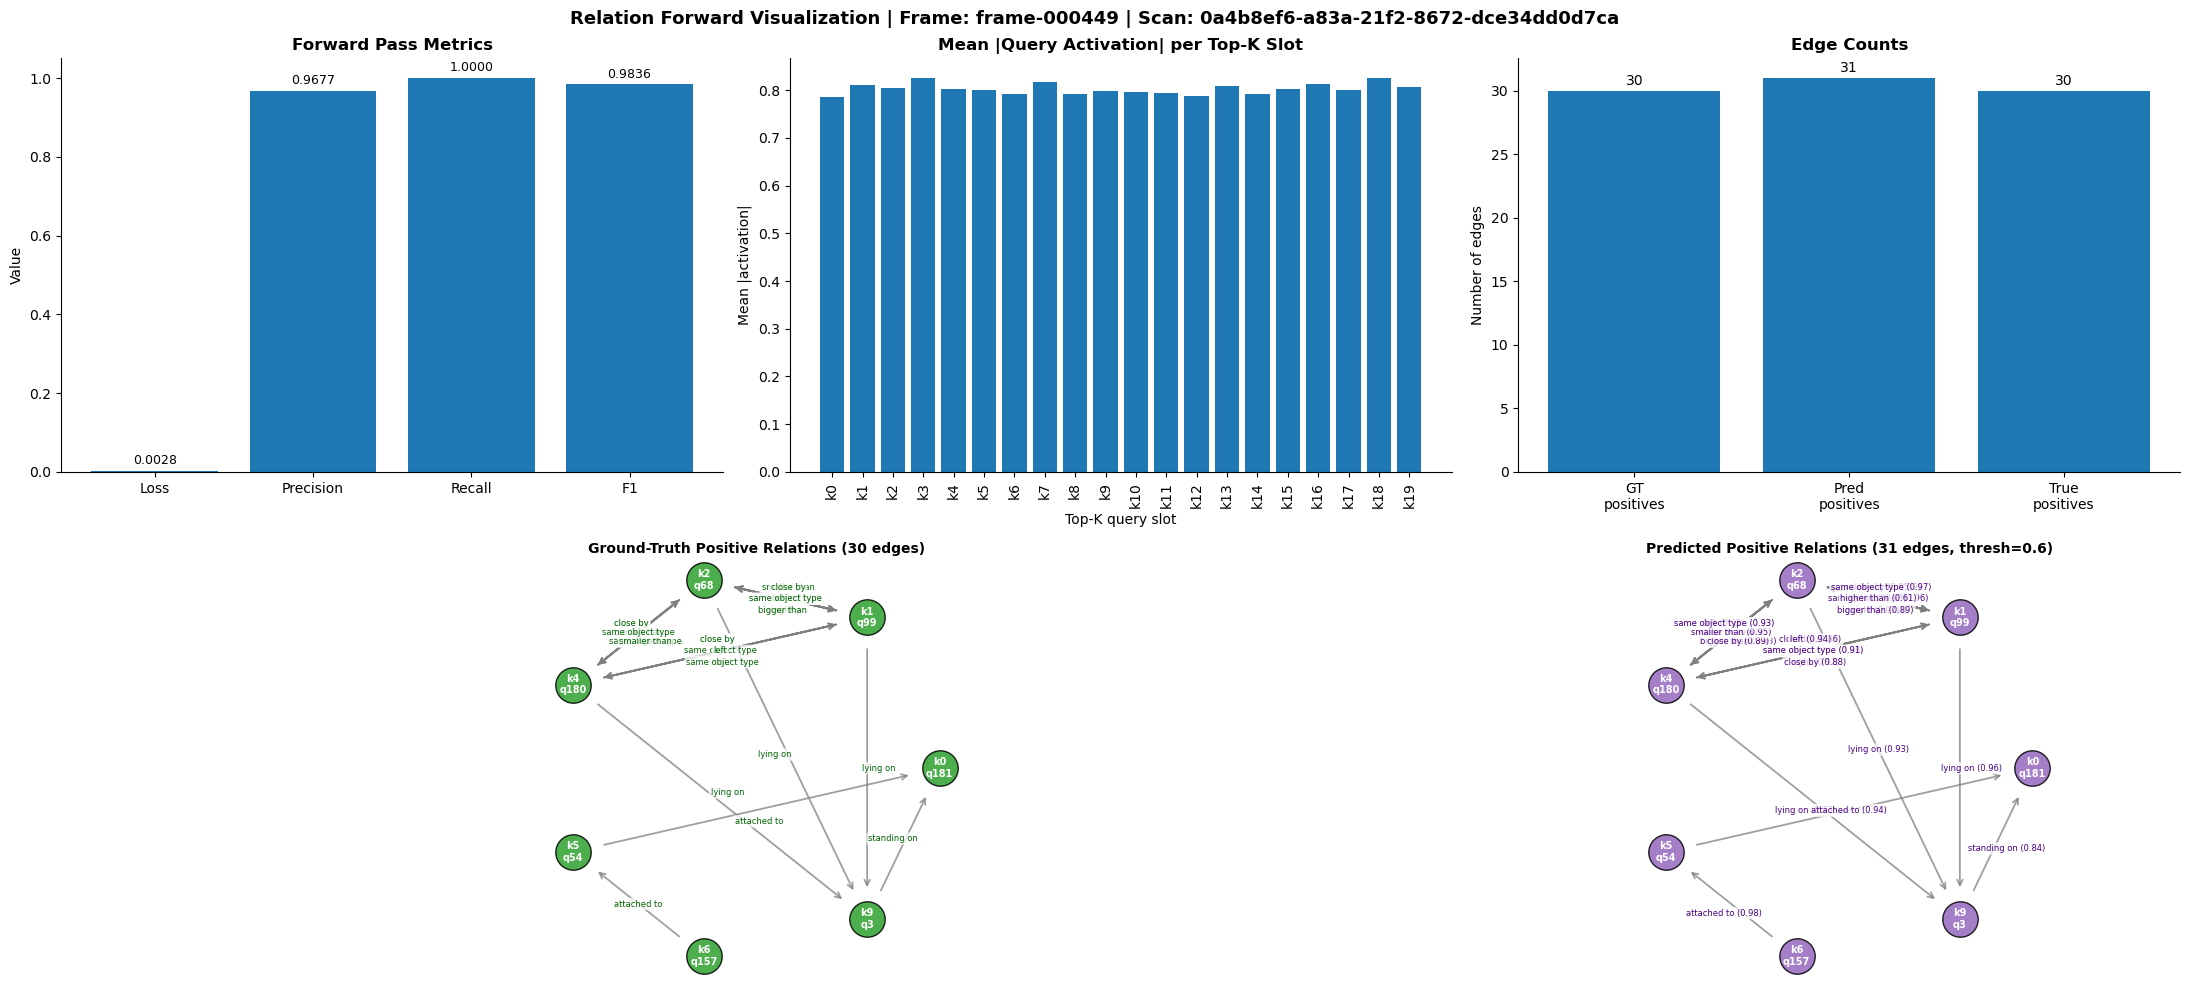


── Top-10 Predicted Positive Edges ──
  k 6/q157 → k 5/q 54 [attached to] score=0.9817
  k 2/q 68 → k 1/q 99 [same object type] score=0.9720
  k 2/q 68 → k 1/q 99 [right] score=0.9686
  k 1/q 99 → k 2/q 68 [same object type] score=0.9617
  k 1/q 99 → k 9/q  3 [lying on] score=0.9605
  k 4/q180 → k 2/q 68 [smaller than] score=0.9547
  k 1/q 99 → k 2/q 68 [left] score=0.9530
  k 2/q 68 → k 1/q 99 [close by] score=0.9528
  k 1/q 99 → k 2/q 68 [close by] score=0.9435
  k 4/q180 → k 1/q 99 [left] score=0.9387

── All Ground-Truth Positive Edges ──
  k 1/q 99 → k 2/q 68 [left]
  k 1/q 99 → k 2/q 68 [front]
  k 1/q 99 → k 2/q 68 [close by]
  k 1/q 99 → k 2/q 68 [smaller than]
  k 1/q 99 → k 2/q 68 [same object type]
  k 1/q 99 → k 4/q180 [right]
  k 1/q 99 → k 4/q180 [close by]
  k 1/q 99 → k 4/q180 [same object type]
  k 1/q 99 → k 9/q  3 [lying on]
  k 2/q 68 → k 1/q 99 [right]
  k 2/q 68 → k 1/q 99 [behind]
  k 2/q 68 → k 1/q 99 [close by]
  k 2/q 68 → k 1/q 99 [bigger than]
  k 2/q 68 → 

In [15]:
# ─────────────────────────────────────────────────────────────────
# Cell: Forward Pass Visualization on First Relation JSON File
#       Works with top-K JSONs: queries [20, 256], targets [20, 20, R]
# Prerequisites: Run full training cell first so `rel_model`,
#                `sequence_dir`, and `relation_names` are in scope.
# ─────────────────────────────────────────────────────────────────

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────
PRED_THRESHOLD = 0.6   # use same threshold as training/eval
sequence_dir = scans_root/"0a4b8ef6-a83a-21f2-8672-dce34dd0d7ca" / "sequence"
json_files = sorted(sequence_dir.glob("frame-*.relation.json"))

if not json_files:
    raise FileNotFoundError(
        f"No .relation.json files found in {sequence_dir}. "
        "Run the top-K relation dataset builder first."
    )

# Pick first JSON with positives if possible
first_json_path = None
for p in json_files:
    with open(p, "r", encoding="utf-8") as f:
        tmp = json.load(f)
    if np.array(tmp["relationship_targets"], dtype=np.uint8).sum() > 0:
        first_json_path = p
        break


first_json_path = json_files[500]

print(f"Loading: {first_json_path.name}")

with open(first_json_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

frame_id = sample["frame_id"]
scan_id_sample = sample["scan_id"]
relation_names = sample["relation_names"]
num_relations = len(relation_names)
meta = sample.get("metadata", {})

queries_np = np.array(sample["queries"], dtype=np.float32)                 # [20, D]
targets_np = np.array(sample["relationship_targets"], dtype=np.uint8)      # [20, 20, R]

topk_indices = meta.get("topk_indices", list(range(queries_np.shape[0])))

queries_t = torch.tensor(queries_np, dtype=torch.float32).unsqueeze(0)     # [1, 20, D]
targets_t = torch.tensor(targets_np, dtype=torch.float32).unsqueeze(0)     # [1, 20, 20, R]

print(f"Frame: {frame_id} | Scan: {scan_id_sample}")
print(f"Queries: {tuple(queries_t.shape)} | Targets: {tuple(targets_t.shape)}")
print(f"GT positives: {int(targets_np.sum())}")
print(f"Relation classes: {num_relations}")
print(f"Top-K original query indices: {topk_indices}")

# ── Forward pass ──────────────────────────────────────────────────
device = next(rel_model.parameters()).device
rel_model.eval()

queries_t = queries_t.to(device)
targets_t = targets_t.to(device)

with torch.inference_mode():
    rel_logits = rel_model(queries_t)                 # [1, 20, 20, R]
    rel_probs = torch.sigmoid(rel_logits)

criterion_vis = torch.nn.BCEWithLogitsLoss()
loss_val = criterion_vis(rel_logits, targets_t).item()

pred_bin = (rel_probs > PRED_THRESHOLD).float()

tp = (pred_bin * targets_t).sum().item()
fp = (pred_bin * (1.0 - targets_t)).sum().item()
fn = ((1.0 - pred_bin) * targets_t).sum().item()

eps = 1e-8
precision = tp / (tp + fp + eps)
recall = tp / (tp + fn + eps)
f1 = 2 * precision * recall / (precision + recall + eps)

print(f"\n── Forward Pass Metrics | threshold={PRED_THRESHOLD} ──")
print(f"BCE Loss: {loss_val:.6f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"Pred positives: {int(pred_bin.sum().item())}")
print(f"GT positives: {int(targets_t.sum().item())}")

# ── Extract GT and predicted edges ────────────────────────────────
gt_targets_np = targets_np
pred_probs_np = rel_probs[0].detach().cpu().numpy()

gt_edges = []
pred_edges = []

num_queries = gt_targets_np.shape[0]

# Predicted positives: count every relation class above threshold
for src_q in range(num_queries):
    for dst_q in range(num_queries):
        if src_q == dst_q:
            continue

        # GT positives
        for r in range(num_relations):
            if gt_targets_np[src_q, dst_q, r] == 1:
                gt_edges.append((src_q, dst_q, relation_names[r]))

        # Pred positives: ALL relations above threshold, not only argmax
        for r in range(num_relations):
            score = float(pred_probs_np[src_q, dst_q, r])
            if score >= PRED_THRESHOLD:
                pred_edges.append((src_q, dst_q, relation_names[r], score))

print(f"\nGT positive edges found: {len(gt_edges)}")
print(f"Pred positive edges found: {len(pred_edges)}")


# ── Draw graph helper ─────────────────────────────────────────────
def _draw_relation_graph(
    ax,
    edges,
    title,
    node_color="tab:blue",
    edge_color="tab:gray",
    label_color="darkred",
    show_score=False,
):
    if not edges:
        ax.set_title(title)
        ax.text(
            0,
            0,
            "No edges to display",
            ha="center",
            va="center",
            fontsize=11,
            color="tab:red",
        )
        ax.axis("off")
        return

    nodes = sorted({e[0] for e in edges} | {e[1] for e in edges})
    n = len(nodes)

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

    pos = {
        nd: np.array([np.cos(a), np.sin(a)], dtype=np.float32)
        for nd, a in zip(nodes, angles)
    }

    for nd in nodes:
        x, y = pos[nd]

        original_q = topk_indices[nd] if nd < len(topk_indices) else nd

        ax.scatter(
            x,
            y,
            s=650,
            c=node_color,
            alpha=0.85,
            edgecolors="black",
            zorder=3,
        )

        ax.text(
            x,
            y,
            f"k{nd}\nq{original_q}",
            ha="center",
            va="center",
            fontsize=7,
            color="white",
            fontweight="bold",
            zorder=4,
        )

    for idx, edge in enumerate(edges):
        src_q, dst_q, rel_name = edge[0], edge[1], edge[2]
        score = edge[3] if len(edge) > 3 else None

        src_xy = pos[src_q]
        dst_xy = pos[dst_q]

        vec = dst_xy - src_xy
        norm = np.linalg.norm(vec)

        if norm < 1e-8:
            continue

        unit = vec / norm
        start = src_xy + unit * 0.15
        end = dst_xy - unit * 0.15

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(
                arrowstyle="->",
                lw=1.3,
                color=edge_color,
                alpha=0.75,
            ),
            zorder=2,
        )

        mid = (start + end) * 0.5
        perp = np.array([-unit[1], unit[0]], dtype=np.float32)
        offset = ((idx % 3) - 1) * 0.06
        text_pos = mid + perp * offset

        label = (
            f"{rel_name} ({score:.2f})"
            if show_score and score is not None
            else rel_name
        )

        ax.text(
            text_pos[0],
            text_pos[1],
            label,
            fontsize=6,
            color=label_color,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.75,
                edgecolor="none",
            ),
            zorder=5,
        )

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


# ── Plot ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 10))

fig.suptitle(
    f"Relation Forward Visualization | Frame: {frame_id} | Scan: {scan_id_sample}",
    fontsize=13,
    fontweight="bold",
)

# Metrics
ax_bar = fig.add_subplot(2, 3, 1)

metrics = {
    "Loss": loss_val,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
}

bars = ax_bar.bar(list(metrics.keys()), list(metrics.values()))
ax_bar.set_ylim(0, max(1.05, loss_val * 1.1))
ax_bar.set_title("Forward Pass Metrics", fontweight="bold")
ax_bar.set_ylabel("Value")

for bar, val in zip(bars, metrics.values()):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax_bar.spines[["top", "right"]].set_visible(False)

# Query activations
ax_heat = fig.add_subplot(2, 3, 2)

mean_act = np.abs(queries_np).mean(axis=1)  # [20]

ax_heat.bar(np.arange(len(mean_act)), mean_act, width=0.8)
ax_heat.set_title("Mean |Query Activation| per Top-K Slot", fontweight="bold")
ax_heat.set_xlabel("Top-K query slot")
ax_heat.set_ylabel("Mean |activation|")
ax_heat.set_xticks(np.arange(len(mean_act)))
ax_heat.set_xticklabels([f"k{i}" for i in range(len(mean_act))], rotation=90)
ax_heat.spines[["top", "right"]].set_visible(False)

# Counts
ax_cnt = fig.add_subplot(2, 3, 3)

categories = ["GT\npositives", "Pred\npositives", "True\npositives"]
counts = [len(gt_edges), len(pred_edges), int(tp)]

ax_cnt.bar(categories, counts)
ax_cnt.set_title("Edge Counts", fontweight="bold")
ax_cnt.set_ylabel("Number of edges")

for i, v in enumerate(counts):
    ax_cnt.text(i, v + 0.2, str(v), ha="center", va="bottom", fontsize=10)

ax_cnt.spines[["top", "right"]].set_visible(False)

# GT graph
ax_gt = fig.add_subplot(2, 3, (4, 5))

_draw_relation_graph(
    ax_gt,
    gt_edges,
    title=f"Ground-Truth Positive Relations ({len(gt_edges)} edges)",
    node_color="tab:green",
    edge_color="tab:gray",
    label_color="darkgreen",
)

# Pred graph
ax_pred = fig.add_subplot(2, 3, 6)

_draw_relation_graph(
    ax_pred,
    pred_edges,
    title=f"Predicted Positive Relations ({len(pred_edges)} edges, thresh={PRED_THRESHOLD})",
    node_color="tab:purple",
    edge_color="tab:gray",
    label_color="indigo",
    show_score=True,
)

plt.tight_layout()
plt.show()

# ── Print top predicted edges ─────────────────────────────────────
print("\n── Top-10 Predicted Positive Edges ──")

top_edges = sorted(pred_edges, key=lambda x: x[3], reverse=True)[:10]

if top_edges:
    for src_q, dst_q, rel_name, score in top_edges:
        src_orig = topk_indices[src_q] if src_q < len(topk_indices) else src_q
        dst_orig = topk_indices[dst_q] if dst_q < len(topk_indices) else dst_q

        print(
            f"  k{src_q:>2}/q{src_orig:>3} → "
            f"k{dst_q:>2}/q{dst_orig:>3} "
            f"[{rel_name}] score={score:.4f}"
        )
else:
    print("  (none above threshold)")


print("\n── All Ground-Truth Positive Edges ──")

if gt_edges:
    for src_q, dst_q, rel_name in gt_edges:
        src_orig = topk_indices[src_q] if src_q < len(topk_indices) else src_q
        dst_orig = topk_indices[dst_q] if dst_q < len(topk_indices) else dst_q

        print(
            f"  k{src_q:>2}/q{src_orig:>3} → "
            f"k{dst_q:>2}/q{dst_orig:>3} "
            f"[{rel_name}]"
        )
else:
    print("  (no GT positive edges in this frame)")

`label_ids_to_fuse` unset. No instance will be fused.


Mask2Former output:
  class logits: (1, 200, 151)
  mask logits : (1, 200, 96, 96)
  queries     : (1, 200, 256)
  segments    : 17

Top-K queries:
  k00 | old_query=054 | score=0.9998 | label=wall
  k01 | old_query=037 | score=0.9995 | label=ceiling
  k02 | old_query=061 | score=0.9993 | label=painting
  k03 | old_query=003 | score=0.9987 | label=bed 
  k04 | old_query=068 | score=0.9980 | label=light
  k05 | old_query=122 | score=0.9962 | label=pillow
  k06 | old_query=077 | score=0.9957 | label=lamp
  k07 | old_query=157 | score=0.9954 | label=table
  k08 | old_query=035 | score=0.9951 | label=blind
  k09 | old_query=181 | score=0.9896 | label=floor
  k10 | old_query=175 | score=0.9894 | label=lamp
  k11 | old_query=009 | score=0.9831 | label=pillow
  k12 | old_query=142 | score=0.9800 | label=cushion
  k13 | old_query=032 | score=0.9764 | label=cushion
  k14 | old_query=091 | score=0.9290 | label=pillow
  k15 | old_query=015 | score=0.9288 | label=windowpane
  k16 | old_query=051 |

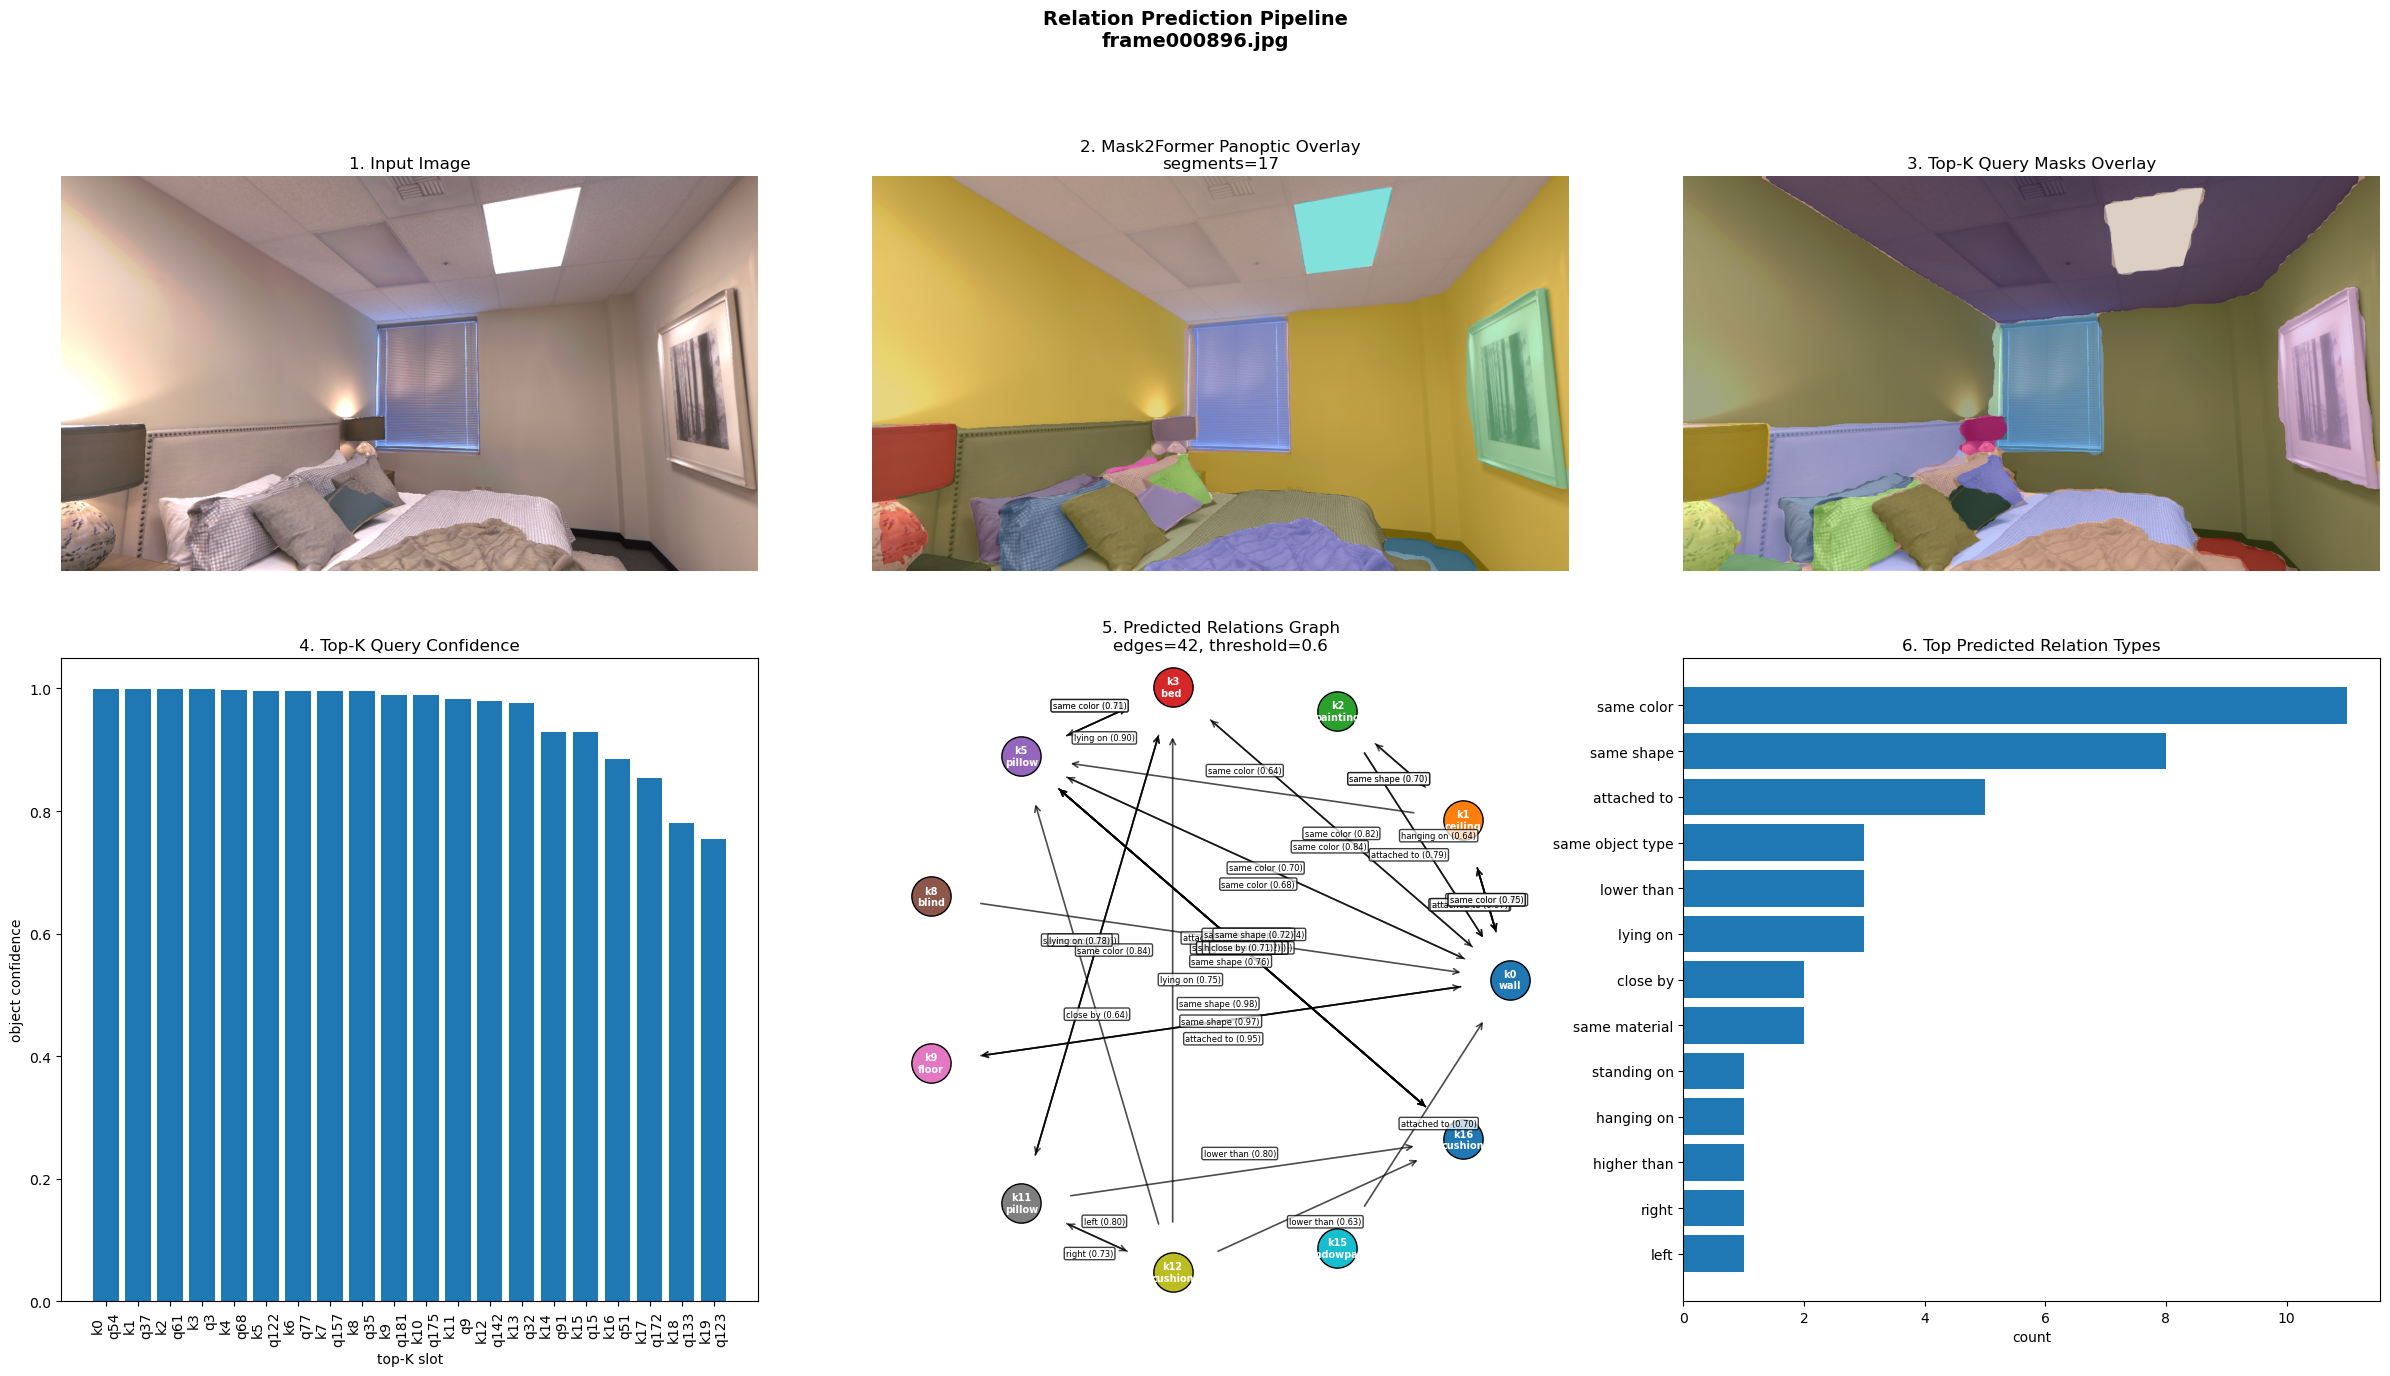

In [16]:
# ─────────────────────────────────────────────────────────────────
# Cell: Predict relations from ONE image path, no relation JSON needed
# Uses:
#   - Mask2Former → queries / masks / classes
#   - RelationHead / rel_model → relationship prediction
# Plots:
#   1. original image
#   2. panoptic segmentation
#   3. top-K query masks
#   4. query confidence bars
#   5. predicted relation graph
# ─────────────────────────────────────────────────────────────────

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# =========================
# Config
# =========================
image_path = "/home/abdou/Projects/Python/RTSGS/Datasets/Replica/ThirdParty/Replica/room1/results/frame000896.jpg"

checkpoint = "facebook/mask2former-swin-large-ade-panoptic"
TOP_K = 20
REL_THRESHOLD = 0.6

relationships_txt = "/home/abdou/Projects/Python/RTSGS/Datasets/3DSSG/3DSSG/relationships.txt"

required_vars = ["rel_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing: {missing}. Run your trained relation-head cell first.")

# =========================
# Load relation names
# =========================
with open(relationships_txt, "r", encoding="utf-8") as f:
    relation_names = [line.strip() for line in f if line.strip()]

# =========================
# Load image
# =========================
image = Image.open(image_path).convert("RGB")

# Match your dataset orientation
#image = image.rotate(-90, expand=True)

device = next(rel_model.parameters()).device
rel_model.eval()

# =========================
# Load Mask2Former
# =========================
processor = AutoImageProcessor.from_pretrained(checkpoint)
seg_model = Mask2FormerForUniversalSegmentation.from_pretrained(checkpoint).to(device)
seg_model.eval()

inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# =========================
# Mask2Former forward
# =========================
with torch.inference_mode():
    outputs = seg_model(**inputs)

    panoptic = processor.post_process_panoptic_segmentation(
        outputs,
        target_sizes=[image.size[::-1]],
        threshold=0.3,
        mask_threshold=0.3,
        overlap_mask_area_threshold=0.7,
    )[0]

predicted_panoptic_map = panoptic["segmentation"].detach().cpu().numpy()
segments_info = panoptic["segments_info"]

print("Mask2Former output:")
print("  class logits:", tuple(outputs.class_queries_logits.shape))
print("  mask logits :", tuple(outputs.masks_queries_logits.shape))
print("  queries     :", tuple(outputs.transformer_decoder_last_hidden_state.shape))
print("  segments    :", len(segments_info))

# =========================
# Select top-K queries
# =========================
class_logits = outputs.class_queries_logits[0]      # [200, C+1]
query_embeds = outputs.transformer_decoder_last_hidden_state[0]  # [200, 256]
mask_logits = outputs.masks_queries_logits[0]       # [200, H, W]

probs = F.softmax(class_logits, dim=-1)

# ignore no-object class
query_scores, query_labels = probs[:, :-1].max(dim=-1)

topk = torch.topk(query_scores, k=TOP_K)

topk_indices = topk.indices.detach().cpu().tolist()
topk_scores = topk.values.detach().cpu().tolist()
topk_labels = query_labels[topk.indices].detach().cpu().tolist()

topk_queries = query_embeds[topk.indices].unsqueeze(0)  # [1, 20, 256]

print("\nTop-K queries:")
for rank, (qid, score, label_id) in enumerate(zip(topk_indices, topk_scores, topk_labels)):
    label_name = seg_model.config.id2label.get(int(label_id), "unknown")
    print(f"  k{rank:02d} | old_query={qid:03d} | score={score:.4f} | label={label_name}")

# =========================
# Relation-head inference
# =========================
with torch.inference_mode():
    rel_logits = rel_model(topk_queries.to(device))       # [1, 20, 20, R]
    rel_probs = torch.sigmoid(rel_logits)[0].cpu().numpy()

print("\nRelation head output:")
print("  rel_logits:", tuple(rel_logits.shape))
print("  rel_probs :", rel_probs.shape)

# =========================
# Extract predicted edges
# Multi-label: keep every relation above threshold
# =========================
pred_edges = []

for src_k in range(TOP_K):
    for dst_k in range(TOP_K):
        if src_k == dst_k:
            continue

        for rel_id in range(rel_probs.shape[-1]):
            score = float(rel_probs[src_k, dst_k, rel_id])

            if score >= REL_THRESHOLD:
                rel_name = (
                    relation_names[rel_id]
                    if rel_id < len(relation_names)
                    else f"rel_{rel_id}"
                )

                pred_edges.append({
                    "src_k": src_k,
                    "dst_k": dst_k,
                    "src_old_query": topk_indices[src_k],
                    "dst_old_query": topk_indices[dst_k],
                    "src_label": seg_model.config.id2label.get(int(topk_labels[src_k]), "unknown"),
                    "dst_label": seg_model.config.id2label.get(int(topk_labels[dst_k]), "unknown"),
                    "rel_id": rel_id,
                    "rel_name": rel_name,
                    "score": score,
                })

pred_edges = sorted(pred_edges, key=lambda x: x["score"], reverse=True)

print(f"\nPredicted relations above threshold {REL_THRESHOLD}: {len(pred_edges)}")
for e in pred_edges[:30]:
    print(
        f"k{e['src_k']:02d}:{e['src_label']} "
        f"--[{e['rel_name']} {e['score']:.3f}]--> "
        f"k{e['dst_k']:02d}:{e['dst_label']}"
    )

# =========================
# Visualization helpers
# =========================
def colorize_id_map(id_map):
    unique_ids = np.unique(id_map)
    rng = np.random.default_rng(0)
    colors = rng.random((len(unique_ids), 3), dtype=np.float32)

    out = np.zeros((*id_map.shape, 3), dtype=np.float32)
    for i, uid in enumerate(unique_ids):
        out[id_map == uid] = colors[i]
    return out


def draw_relation_graph(ax, edges, title):
    if len(edges) == 0:
        ax.set_title(title)
        ax.text(0, 0, "No relations predicted", ha="center", va="center", color="red")
        ax.axis("off")
        return

    nodes = sorted(set([e["src_k"] for e in edges] + [e["dst_k"] for e in edges]))
    n = len(nodes)

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = {
        node: np.array([np.cos(a), np.sin(a)], dtype=np.float32)
        for node, a in zip(nodes, angles)
    }

    for node in nodes:
        x, y = pos[node]
        label_name = seg_model.config.id2label.get(int(topk_labels[node]), "unknown")

        ax.scatter(x, y, s=800, edgecolors="black", zorder=3)
        ax.text(
            x,
            y,
            f"k{node}\n{label_name[:10]}",
            ha="center",
            va="center",
            fontsize=7,
            color="white",
            fontweight="bold",
            zorder=4,
        )

    # draw only top 40 to avoid unreadable graph
    for idx, e in enumerate(edges[:40]):
        src = e["src_k"]
        dst = e["dst_k"]

        src_xy = pos[src]
        dst_xy = pos[dst]

        vec = dst_xy - src_xy
        norm = np.linalg.norm(vec)
        if norm < 1e-8:
            continue

        unit = vec / norm
        start = src_xy + unit * 0.16
        end = dst_xy - unit * 0.16

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle="->", lw=1.2, alpha=0.7),
            zorder=2,
        )

        mid = (start + end) * 0.5
        perp = np.array([-unit[1], unit[0]], dtype=np.float32)
        text_pos = mid + perp * (((idx % 3) - 1) * 0.06)

        ax.text(
            text_pos[0],
            text_pos[1],
            f"{e['rel_name']} ({e['score']:.2f})",
            fontsize=6,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.75),
            zorder=5,
        )

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


# =========================
# Prepare plots
# =========================
image_np = np.array(image).astype(np.float32) / 255.0

panoptic_color = colorize_id_map(predicted_panoptic_map)
panoptic_overlay = 0.5 * image_np + 0.5 * panoptic_color

# Top-K mask visualization
topk_masks = torch.sigmoid(mask_logits[topk.indices]).detach().cpu().numpy()  # [20, h, w]

mask_h, mask_w = topk_masks.shape[-2:]
img_h, img_w = predicted_panoptic_map.shape

# Upsample masks to image size
topk_masks_t = torch.tensor(topk_masks).unsqueeze(1)
topk_masks_up = F.interpolate(
    topk_masks_t,
    size=(img_h, img_w),
    mode="bilinear",
    align_corners=False,
).squeeze(1).numpy()

topk_mask_id = np.zeros((img_h, img_w), dtype=np.int32)

for k in range(TOP_K):
    mask = topk_masks_up[k] > 0.5
    topk_mask_id[mask] = k + 1

topk_mask_color = colorize_id_map(topk_mask_id)
topk_overlay = 0.5 * image_np + 0.5 * topk_mask_color

# =========================
# Plot every step
# =========================
fig = plt.figure(figsize=(24, 14))

fig.suptitle(
    f"Relation Prediction Pipeline\n{Path(image_path).name}",
    fontsize=14,
    fontweight="bold",
)

ax1 = fig.add_subplot(2, 3, 1)
ax1.imshow(image)
ax1.set_title("1. Input Image")
ax1.axis("off")

ax2 = fig.add_subplot(2, 3, 2)
ax2.imshow(panoptic_overlay)
ax2.set_title(f"2. Mask2Former Panoptic Overlay\nsegments={len(segments_info)}")
ax2.axis("off")

ax3 = fig.add_subplot(2, 3, 3)
ax3.imshow(topk_overlay)
ax3.set_title("3. Top-K Query Masks Overlay")
ax3.axis("off")

ax4 = fig.add_subplot(2, 3, 4)
ax4.bar(np.arange(TOP_K), topk_scores)
ax4.set_title("4. Top-K Query Confidence")
ax4.set_xlabel("top-K slot")
ax4.set_ylabel("object confidence")
ax4.set_xticks(np.arange(TOP_K))
ax4.set_xticklabels([f"k{i}\nq{topk_indices[i]}" for i in range(TOP_K)], rotation=90)

ax5 = fig.add_subplot(2, 3, 5)
draw_relation_graph(
    ax5,
    pred_edges,
    title=f"5. Predicted Relations Graph\nedges={len(pred_edges)}, threshold={REL_THRESHOLD}",
)

ax6 = fig.add_subplot(2, 3, 6)
edge_counts = {}

for e in pred_edges:
    edge_counts[e["rel_name"]] = edge_counts.get(e["rel_name"], 0) + 1

if len(edge_counts) > 0:
    names = list(edge_counts.keys())
    counts = list(edge_counts.values())
    order = np.argsort(counts)[::-1]

    names = [names[i] for i in order[:15]]
    counts = [counts[i] for i in order[:15]]

    ax6.barh(names[::-1], counts[::-1])
    ax6.set_title("6. Top Predicted Relation Types")
    ax6.set_xlabel("count")
else:
    ax6.text(0.5, 0.5, "No relation types", ha="center", va="center")
    ax6.set_title("6. Top Predicted Relation Types")

plt.tight_layout()
plt.show()